In [1]:
import numpy as np
import os, sys
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import h5py
import corner
import emcee
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

from scipy.interpolate import interp1d
from scipy.integrate import simpson, romb
from scipy.optimize import curve_fit

from popsummary.popresult import PopulationResult

from darksirenpop.utilities.redshift_utils import *
from darksirenpop.utilities.utils import make_nice_plots
from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.priors import *
from darksirenpop.utilities.gw_selection_effects import *

from darksirenpop.run import *
from darksirenpop.likelihood import *
from darksirenpop.worker import run_worker

make_nice_plots()


opening existing popsummary file: /home/lucas/Documents/PhD/gw_data/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/ligo/skymap/io/events/ligolw.py:26: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_pdfs(posteriors, axis):
    posteriors -= np.max(posteriors, axis=0)
    pdf = np.exp(posteriors)
    norms = simpson(y=pdf, x=axis, axis=0)  # Simpson should be fine...
    pdfs = pdf / norms
    return pdfs


<!-- # Inputs when NOT fitting z_max as well -->

In [3]:
# Define constants and priors

HYPERPARAM_DIR = '/home/lucas/Documents/PhD/generated_data/alt_origin_hyperparameters'

ndim = 4
nwalkers = 100
nsteps = 5000
LTHRESH_STRING = '45.5'

par_names = np.array(['b', 'c', 'd', 'fagn'])
par_names_latex = np.array([r'$\gamma$', r'$1 + z_{\rm peak}$', r'$\kappa$', r'$f_{\rm agn}$'])

filename = f"{HYPERPARAM_DIR}/sampler_uniform_priors_withcat_{LTHRESH_STRING}.h5"
backend = emcee.backends.HDFBackend(filename)

# reset if starting a new run
# backend.reset(nwalkers, ndim)


######### GAUSSIAN PRIORS ON MD + UNIFORM ON FAGN #########
# PRIOR_MU = np.array([3.3, 2.55, 6.1])  # b, c, d = low-z PL slope, 1 + z_peak, high-z PL slope
# PRIOR_SIGMA = np.array([0.2, 0.09, 0.2])
# FAGN_PRIOR = [0, 1]

# def log_prior(theta):
#     theta = np.asarray(theta)
#     gauss_params = theta[:3]
#     fagn = theta[3]

#     # Gaussian priors for first 3 parameters
#     logp_gauss = -0.5 * np.sum(
#         ((gauss_params - PRIOR_MU) / PRIOR_SIGMA) ** 2
#         + np.log(2 * np.pi * PRIOR_SIGMA**2)
#     )

#     # Uniform prior for fagn
#     if FAGN_PRIOR[0] <= fagn <= FAGN_PRIOR[1]:
#         logp_fagn = 0.0   # constant, can omit
#     else:
#         logp_fagn = -np.inf

#     return logp_gauss + logp_fagn


# # Initial positions
# pos = np.zeros((nwalkers, ndim))
# pos[:, :len(PRIOR_MU)] = np.random.normal(PRIOR_MU, PRIOR_SIGMA, size=(nwalkers, len(PRIOR_MU)))
# pos[:, -1] = np.random.uniform(FAGN_PRIOR[0], FAGN_PRIOR[1], nwalkers)

####################################


######### UNIFORM PRIORS #########
b_prior = [-10, 10]
c_prior = [1, 3.5]
d_prior = [0, 10]
fagn_prior = [0, 1]

MCMC_PRIOR = np.array([b_prior, c_prior, d_prior, fagn_prior])

def log_prior(theta):
    '''Uniform prior in all parameters'''
    for i in range(0, len(theta)):
        if (theta[i] < MCMC_PRIOR[i, 0]) or (theta[i] > MCMC_PRIOR[i, 1]):
            return -np.inf
    return 0.0

# Initial positions
pos = np.zeros((nwalkers, ndim))
pos[:, 0] = np.random.uniform(b_prior[0], b_prior[1], nwalkers)
pos[:, 1] = np.random.uniform(c_prior[0], c_prior[1], nwalkers)
pos[:, 2] = np.random.uniform(d_prior[0], d_prior[1], nwalkers)
pos[:, 3] = np.random.uniform(fagn_prior[0], fagn_prior[1], nwalkers)

####################################


# def log_prior(theta):
#     '''Gaussian prior in all parameters'''
#     theta = np.asarray(theta)

#     return -0.5 * np.sum(
#         ((theta - prior_mu) / prior_sigma) ** 2
#         + np.log(2 * np.pi * prior_sigma**2)
#     )


<!-- # Input when fitting z_max -->


In [4]:
# # Define constants and priors
# snr_thr = 10
# far_thr = 1
# Ngw = 256

# ndim = 5
# nwalkers = 100
# nsteps = 5000

# par_names = np.array(['b', 'c', 'd', 'fagn', 'zmax'])
# par_names_latex = np.array([r'$\gamma$', r'$1 + z_{\rm peak}$', r'$\alpha$', r'$f_{\rm agn}$', r'$z_{\rm max}$'])

# filename = f"{HYPERPARAM_DIR}/sampler_uniform_zmax_priors.h5"
# backend = emcee.backends.HDFBackend(filename)

# # reset if starting a new run
# # backend.reset(nwalkers, ndim)


# ######### GAUSSIAN PRIORS ON MD + UNIFORM ON FAGN #########
# # PRIOR_MU = np.array([3.3, 2.55, 6.1])  # b, c, d = low-z PL slope, 1 + z_peak, high-z PL slope
# # PRIOR_SIGMA = np.array([0.2, 0.09, 0.2])
# # FAGN_PRIOR = [0, 1]

# # def log_prior(theta):
# #     theta = np.asarray(theta)
# #     gauss_params = theta[:3]
# #     fagn = theta[3]

# #     # Gaussian priors for first 3 parameters
# #     logp_gauss = -0.5 * np.sum(
# #         ((gauss_params - PRIOR_MU) / PRIOR_SIGMA) ** 2
# #         + np.log(2 * np.pi * PRIOR_SIGMA**2)
# #     )

# #     # Uniform prior for fagn
# #     if FAGN_PRIOR[0] <= fagn <= FAGN_PRIOR[1]:
# #         logp_fagn = 0.0   # constant, can omit
# #     else:
# #         logp_fagn = -np.inf

# #     return logp_gauss + logp_fagn


# # # Initial positions
# # pos = np.zeros((nwalkers, ndim))
# # pos[:, :len(PRIOR_MU)] = np.random.normal(PRIOR_MU, PRIOR_SIGMA, size=(nwalkers, len(PRIOR_MU)))
# # pos[:, -1] = np.random.uniform(FAGN_PRIOR[0], FAGN_PRIOR[1], nwalkers)

# ####################################


# ######### UNIFORM PRIORS #########
# b_prior = [-10, 10]
# c_prior = [1, 3.5]
# d_prior = [0, 10]
# fagn_prior = [0, 1]
# zmax_prior = [2, 10]

# MCMC_PRIOR = np.array([b_prior, c_prior, d_prior, fagn_prior, zmax_prior])

# def log_prior(theta):
#     '''Uniform prior in all parameters'''
#     for i in range(0, len(theta)):
#         if (theta[i] < MCMC_PRIOR[i, 0]) or (theta[i] > MCMC_PRIOR[i, 1]):
#             return -np.inf
#     return 0.0

# # Initial positions
# pos = np.zeros((nwalkers, ndim))
# pos[:, 0] = np.random.uniform(b_prior[0], b_prior[1], nwalkers)
# pos[:, 1] = np.random.uniform(c_prior[0], c_prior[1], nwalkers)
# pos[:, 2] = np.random.uniform(d_prior[0], d_prior[1], nwalkers)
# pos[:, 3] = np.random.uniform(fagn_prior[0], fagn_prior[1], nwalkers)
# pos[:, 4] = np.random.uniform(zmax_prior[0], zmax_prior[1], nwalkers)

# ####################################


# # def log_prior(theta):
# #     '''Gaussian prior in all parameters'''
# #     theta = np.asarray(theta)

# #     return -0.5 * np.sum(
# #         ((theta - prior_mu) / prior_sigma) ** 2
# #         + np.log(2 * np.pi * prior_sigma**2)
# #     )


In [5]:
def get_diagnostics(sampler, ndim=ndim, burnin=0, acceptance_fraction_low=0, acceptance_fraction_high=1, remove_extra_walker_idx=[]):

    print(sampler.acceptance_fraction)
    good_walkers = np.where((sampler.acceptance_fraction >= acceptance_fraction_low) & (sampler.acceptance_fraction <= acceptance_fraction_high))[0]
    mask = ~np.isin(good_walkers, remove_extra_walker_idx)
    good_walkers = good_walkers[mask]
        
    print(f'There are {len(good_walkers)} good walkers.')

    samples = sampler.get_chain()
    log_prob = sampler.get_log_prob()
    median_log_prob = np.median(log_prob[burnin:, good_walkers])
    print(f'lnL = {median_log_prob:.1f} +/- {np.std(log_prob[burnin:, good_walkers]):.1f}')

    fname_string = ''
    for name in par_names:
        fname_string += f'_{name}'
    # np.save(os.path.join(DATA_DIR, f'mcmc_logprob{fname_string}_{PRIOR}prior_{LABEL}'), log_prob[burnin:, good_walkers])
    # np.save(os.path.join(DATA_DIR, f'mcmc_samples{fname_string}_{PRIOR}prior_{LABEL}'), samples[burnin:, good_walkers, :])


    fig, axes = plt.subplots(ndim, figsize=(10, 10), sharex=True)
    for i in range(ndim):
        chains = samples[:, good_walkers, i]
        ax = axes[i]
        ax.plot(chains, "k", alpha=0.3)
        ax.vlines(burnin, np.min(chains), np.max(chains), linestyle='dashed', color='red')
        ax.set_xlim(0, chains.shape[0] - 1)
        ax.set_ylabel(f'{par_names_latex[i]}')
        ax.yaxis.set_label_coords(-0.1, 0.5)
    axes[-1].set_xlabel("step number")
    # plt.savefig(os.path.join(PLOT_DIR, f'walkers{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
    plt.show()


    plt.figure()
    plt.plot(log_prob[:, good_walkers])
    xmax = log_prob.shape[0] - 1
    ymin = median_log_prob * 0.95
    ymax = median_log_prob * 1.05
    plt.ylim(ymin, ymax)
    plt.xlim(0, xmax)
    plt.hlines(median_log_prob, 0, xmax, linestyle='dashed', color='black', label=f'Median after burnin')
    plt.vlines(burnin, ymin, ymax, linestyle='dashed', color='red', label='Burnin')
    plt.xlabel('step number')
    plt.ylabel('Log probability')
    plt.legend()
    # plt.savefig(os.path.join(PLOT_DIR, f'logprob{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
    plt.show()


    flat_samples = samples[burnin:, good_walkers, :].reshape(-1, ndim)
    fig = corner.corner(
        flat_samples, 
        labels=[f'{par_names_latex[i]}' for i in range(ndim)],
        show_titles=True,
        title_fmt='.2f')
    # plt.savefig(os.path.join(PLOT_DIR, f'corner{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
    plt.show()


In [6]:
zmodel = 'madau'
thresh = f'{LTHRESH_STRING}_kulkarni'
label = '_zleq3_final_kmax5_gwtc5_luminformed_smoothcorr'
agn_json_path = f'/home/lucas/Documents/PhD/gw_data/real_output_{zmodel}{label}.json'
# json_emptycat = f'/home/lucas/Documents/PhD/gw_data/real_output_nocat_{zmodel}{label}.json'

with open(agn_json_path, "r") as f:
    data = json.load(f)
    gw_evidence_dict = data[str(thresh)]

def log_likelihood_plotting(theta):
    agn_zcut = 3.0  # 1.5

    b, c, d = theta
    rate_param_dict = {'b': b, 'c': c, 'd': d}

    cfg = Config()
    cfg.RATE_PARAMETERS = rate_param_dict
    cfg.VERBOSE = False
    cfg.THREADING = False
    cfg.REAL_DATA = True
    cfg.OUTFILE = 'none'
    cfg.AGN_DIST_DIR = '/home/lucas/Documents/PhD/generated_data/em'
    cfg.CATALOG_PATH = '/home/lucas/Documents/PhD/generated_data/em/quaia_zleq3_withlumcorr.csv'  # '/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv'
    cfg.CMAP_PATH = '/home/lucas/Documents/PhD/completeness_map.fits'
    cfg.ZMIN = 0.000001
    cfg.ZMAX = 10
    cfg.AGN_ZMAX = 10
    cfg.AGN_ZCUT = agn_zcut
    cfg.AGN_ZPRIOR = LTHRESH_STRING
    cfg.LUM_THRESH = LTHRESH_STRING
    cfg.MASK_GALACTIC_PLANE = True
    cfg.ASSUME_PERFECT_REDSHIFT = False
    cfg.AGN_ZERROR = 'quaia'
    cfg.CORRECT_TIME_DILATION = True
    cfg.MERGER_RATE = 'madau'
    # cfg.LABEL = 'samplinggwtc5'
    cfg.finalize()



    with open(cfg.JSON_PATH, "r") as f:
        gw_path_dict = json.load(f)
    gw_keys = list(gw_path_dict.keys())
    gw_fnames = [gw_path_dict[key] for key in gw_keys]

    ### Prepare functions for in the likelihood ###
    if cfg.CORRECT_TIME_DILATION:
        time_dilation_func = lambda z: time_dilation_correction(z)
    else: 
        time_dilation_func = lambda z: np.ones_like(z)
    time_dilation = time_dilation_func(cfg.Z_INTEGRAL_AX)
    zcut = z_cut(cfg.Z_INTEGRAL_AX, zcut=cfg.ZMAX)
    zrate_alt = merger_rate(cfg.Z_INTEGRAL_AX, cfg.MERGER_RATE_EVOLUTION, **cfg.MERGER_RATE_KWARGS)
    p_rate_of_z_alt = time_dilation * zrate_alt * zcut
    PEprior_func = lambda z: uniform_comoving_prior(z, cosmo=cfg.COSMO)
    PEprior = PEprior_func(cfg.Z_INTEGRAL_AX)
    dz, jacobian = get_dz_and_jacobian(cfg)

    alpha_alt = get_alpha_alt(snr_thr=cfg.SNR_THR, far_thr=cfg.FAR_THR, alt_rate_model=cfg.MERGER_RATE, alt_rate_parameters=cfg.RATE_PARAMETERS, zmax=cfg.ZMAX)
    alpha_agn = gw_evidence_dict[gw_keys[0]]['alpha_agn']  # Same for all events


    ### Calculate the integrals in the likelihood ###
    Ngws = len(gw_fnames)  # Due to selection effects not always the same number
    S_agn_incat = np.zeros(Ngws)
    S_agn_outofcat = np.zeros(Ngws)
    S_alt = np.zeros(Ngws)
    for gw_idx, _ in enumerate(gw_fnames):
        gwkey = gw_keys[gw_idx]

        with open(cfg.REAL_ZPOSTS_JSON_PATH, "r") as f:
            gw_zpost_path_dict = json.load(f)
            gw_zpost_path = gw_zpost_path_dict[gwkey]
        with open(cfg.REAL_CW_ZPOSTS_JSON_PATH, "r") as f:
            gw_zpost_cw_path_dict = json.load(f)
            gw_zpost_cw_path = gw_zpost_cw_path_dict[gwkey]
        z, p = np.load(gw_zpost_path)
        z_cw, p_cw = np.load(gw_zpost_cw_path)
        gwpost_interp = CubicSpline(z, p, extrapolate=False)
        gw_redshift_posterior_marginalized_evaluated = gwpost_interp(cfg.Z_INTEGRAL_AX)
        gw_redshift_posterior_marginalized_evaluated[np.isnan(gw_redshift_posterior_marginalized_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros

        if not cfg.MASK_GALACTIC_PLANE:
            gw_redshift_posterior_marginalized_cw_evaluated = gw_redshift_posterior_marginalized_evaluated.copy()
        else:
            gwpost_interp_cw = CubicSpline(z_cw, p_cw, extrapolate=False)
            gw_redshift_posterior_marginalized_cw_evaluated = gwpost_interp_cw(cfg.Z_INTEGRAL_AX)
            gw_redshift_posterior_marginalized_cw_evaluated[np.isnan(gw_redshift_posterior_marginalized_cw_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros'

        background_alt_distribution = uniform_comoving_prior(cfg.Z_INTEGRAL_AX, cosmo=cfg.COSMO)
        alt_redshift_population_prior = background_alt_distribution * p_rate_of_z_alt
        alt_redshift_population_prior /= romb(alt_redshift_population_prior * jacobian, dx=dz)
        salt = romb(y=gw_redshift_posterior_marginalized_evaluated / PEprior * alt_redshift_population_prior * jacobian, dx=dz)

        sagn_incat = gw_evidence_dict[gwkey]['S_agn_incat']
        sagn_outofcat = gw_evidence_dict[gwkey]['S_agn_outcat']

        S_agn_incat[gw_idx] = sagn_incat
        S_agn_outofcat[gw_idx] = sagn_outofcat
        S_alt[gw_idx] = salt

    #     print(f'GW: {gwkey}, Sagn incat: {sagn_incat}, Sagn outcat: {sagn_outofcat}, Salt: {salt}')
    # print(Ngws, alpha_agn, alpha_alt)
    ### Evaluate the likelihood ###
    S_agn_incat = S_agn_incat[~np.isnan(S_agn_incat)]
    S_agn_outofcat = S_agn_outofcat[~np.isnan(S_agn_outofcat)]
    S_alt = S_alt[~np.isnan(S_alt)]

    loglike = np.log(cfg.LOG_LLH_X_AX[None,:] * (S_agn_incat[:,None] + S_agn_outofcat[:,None] - S_alt[:,None]) + S_alt[:,None])
    total_loglike = np.sum(loglike, axis=0)  # Sum over all GWs
    total_loglike -= Ngws * np.log(alpha_agn * cfg.LOG_LLH_X_AX + alpha_alt * (1 - cfg.LOG_LLH_X_AX))  # Correct selection effects

    nans = np.isnan(loglike)
    if np.sum(nans) != 0:
        print('Got NaNs:')
        arr = np.ones_like(cfg.LOG_LLH_X_AX)
        print((arr[None,:] * S_agn_incat[:,None])[nans])
        print((arr[None,:] * S_agn_outofcat[:,None])[nans])
        print((arr[None,:] * S_alt[:,None])[nans])

    log_llh = total_loglike
    
    return log_llh, cfg

# corrected_log_llh_plot, cfg_plot = log_likelihood_plotting(theta=np.array([2.6, 3.2, 6.2]))
corrected_log_llh_plot, cfg_plot = log_likelihood_plotting(theta=np.array([3.3, 2.55, 6.1]))


/home/lucas/Documents/PhD/darksirenpop/utilities/gw_selection_effects.py:223: RuntimeWarning: divide by zero encountered in log
  return np.log(z_pop(z)) + np.log(m_pop(m1, m2))  # TODO: spins


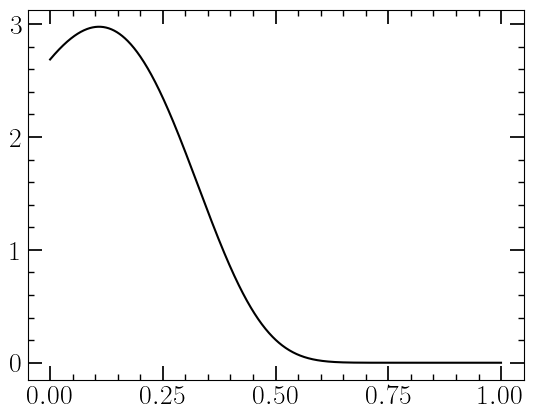

In [7]:
plt.figure()
plt.plot(cfg_plot.LOG_LLH_X_AX, get_pdfs(corrected_log_llh_plot, axis=cfg_plot.LOG_LLH_X_AX), color='black') 
plt.show()

In [8]:
np.seterr(divide='ignore')

zmodel = 'madau'
thresh = f'{LTHRESH_STRING}_kulkarni'
label = '_zleq3_final_kmax5_gwtc5_luminformed_smoothcorr'
agn_json_path = f'/home/lucas/Documents/PhD/gw_data/real_output_{zmodel}{label}.json'
# json_emptycat = f'/home/lucas/Documents/PhD/gw_data/real_output_nocat_{zmodel}{label}.json'

with open(agn_json_path, "r") as f:
    data = json.load(f)
    gw_evidence_dict = data[str(thresh)]

def log_likelihood(theta):
    agn_zcut = 3.0  # 1.5

    b, c, d, fagn = theta
    rate_param_dict = {'b': b, 'c': c, 'd': d}

    cfg = Config()
    cfg.RATE_PARAMETERS = rate_param_dict
    cfg.VERBOSE = False
    cfg.THREADING = False
    cfg.REAL_DATA = True
    cfg.OUTFILE = 'none'
    cfg.AGN_DIST_DIR = '/home/lucas/Documents/PhD/generated_data/em'
    cfg.CATALOG_PATH = '/home/lucas/Documents/PhD/generated_data/em/quaia_zleq3_withlumcorr.csv'  # '/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv'
    cfg.CMAP_PATH = '/home/lucas/Documents/PhD/completeness_map.fits'
    cfg.ZMIN = 0.000001
    cfg.ZMAX = 10
    cfg.AGN_ZMAX = 10
    cfg.AGN_ZCUT = agn_zcut
    cfg.AGN_ZPRIOR = LTHRESH_STRING
    cfg.LUM_THRESH = LTHRESH_STRING
    cfg.MASK_GALACTIC_PLANE = True
    cfg.ASSUME_PERFECT_REDSHIFT = False
    cfg.AGN_ZERROR = 'quaia'
    cfg.CORRECT_TIME_DILATION = True
    cfg.MERGER_RATE = 'madau'
    cfg.LABEL = 'samplinggwtc5'
    cfg.finalize()



    with open(cfg.JSON_PATH, "r") as f:
        gw_path_dict = json.load(f)
    gw_keys = list(gw_path_dict.keys())
    gw_fnames = [gw_path_dict[key] for key in gw_keys]

    ### Prepare functions for in the likelihood ###
    if cfg.CORRECT_TIME_DILATION:
        time_dilation_func = lambda z: time_dilation_correction(z)
    else: 
        time_dilation_func = lambda z: np.ones_like(z)
    time_dilation = time_dilation_func(cfg.Z_INTEGRAL_AX)
    zcut = z_cut(cfg.Z_INTEGRAL_AX, zcut=cfg.ZMAX)
    zrate_alt = merger_rate(cfg.Z_INTEGRAL_AX, cfg.MERGER_RATE_EVOLUTION, **cfg.MERGER_RATE_KWARGS)
    p_rate_of_z_alt = time_dilation * zrate_alt * zcut
    PEprior_func = lambda z: uniform_comoving_prior(z, cosmo=cfg.COSMO)
    PEprior = PEprior_func(cfg.Z_INTEGRAL_AX)
    dz, jacobian = get_dz_and_jacobian(cfg)

    alpha_alt = get_alpha_alt(snr_thr=cfg.SNR_THR, far_thr=cfg.FAR_THR, alt_rate_model=cfg.MERGER_RATE, alt_rate_parameters=cfg.RATE_PARAMETERS, zmax=cfg.ZMAX)
    alpha_agn = gw_evidence_dict[gw_keys[0]]['alpha_agn']  # Same for all events


    ### Calculate the integrals in the likelihood ###
    Ngws = len(gw_fnames)  # Due to selection effects not always the same number
    S_agn_incat = np.zeros(Ngws)
    S_agn_outofcat = np.zeros(Ngws)
    S_alt = np.zeros(Ngws)
    for gw_idx, _ in enumerate(gw_fnames):
        gwkey = gw_keys[gw_idx]

        with open(cfg.REAL_ZPOSTS_JSON_PATH, "r") as f:
            gw_zpost_path_dict = json.load(f)
            gw_zpost_path = gw_zpost_path_dict[gwkey]
        with open(cfg.REAL_CW_ZPOSTS_JSON_PATH, "r") as f:
            gw_zpost_cw_path_dict = json.load(f)
            gw_zpost_cw_path = gw_zpost_cw_path_dict[gwkey]
        z, p = np.load(gw_zpost_path)
        z_cw, p_cw = np.load(gw_zpost_cw_path)
        gwpost_interp = CubicSpline(z, p, extrapolate=False)
        gw_redshift_posterior_marginalized_evaluated = gwpost_interp(cfg.Z_INTEGRAL_AX)
        gw_redshift_posterior_marginalized_evaluated[np.isnan(gw_redshift_posterior_marginalized_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros

        if not cfg.MASK_GALACTIC_PLANE:
            gw_redshift_posterior_marginalized_cw_evaluated = gw_redshift_posterior_marginalized_evaluated.copy()
        else:
            gwpost_interp_cw = CubicSpline(z_cw, p_cw, extrapolate=False)
            gw_redshift_posterior_marginalized_cw_evaluated = gwpost_interp_cw(cfg.Z_INTEGRAL_AX)
            gw_redshift_posterior_marginalized_cw_evaluated[np.isnan(gw_redshift_posterior_marginalized_cw_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros'

        background_alt_distribution = uniform_comoving_prior(cfg.Z_INTEGRAL_AX, cosmo=cfg.COSMO)
        alt_redshift_population_prior = background_alt_distribution * p_rate_of_z_alt
        alt_redshift_population_prior /= romb(alt_redshift_population_prior * jacobian, dx=dz)
        salt = romb(y=gw_redshift_posterior_marginalized_evaluated / PEprior * alt_redshift_population_prior * jacobian, dx=dz)

        sagn_incat = gw_evidence_dict[gwkey]['S_agn_incat']
        sagn_outofcat = gw_evidence_dict[gwkey]['S_agn_outcat']

        S_agn_incat[gw_idx] = sagn_incat
        S_agn_outofcat[gw_idx] = sagn_outofcat
        S_alt[gw_idx] = salt

    ### Evaluate the likelihood ###
    S_agn_incat = S_agn_incat[~np.isnan(S_agn_incat)]
    S_agn_outofcat = S_agn_outofcat[~np.isnan(S_agn_outofcat)]
    S_alt = S_alt[~np.isnan(S_alt)]

    loglike = np.log(cfg.LOG_LLH_X_AX[None,:] * (S_agn_incat[:,None] + S_agn_outofcat[:,None] - S_alt[:,None]) + S_alt[:,None])
    total_loglike = np.sum(loglike, axis=0)  # Sum over all GWs
    total_loglike -= Ngws * np.log(alpha_agn * cfg.LOG_LLH_X_AX + alpha_alt * (1 - cfg.LOG_LLH_X_AX))  # Correct selection effects

    nans = np.isnan(loglike)
    if np.sum(nans) != 0:
        print('Got NaNs:')
        arr = np.ones_like(cfg.LOG_LLH_X_AX)
        print((arr[None,:] * S_agn_incat[:,None])[nans])
        print((arr[None,:] * S_agn_outofcat[:,None])[nans])
        print((arr[None,:] * S_alt[:,None])[nans])

    log_llh = total_loglike


    # log_llh = run_worker(cfg).flatten()
    interped_log_llh = CubicSpline(LOG_LLH_X_AX, log_llh)
    return interped_log_llh(fagn)


def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)



In [9]:
# # sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend)
# # sampler.run_mcmc(pos, nsteps, progress=True)

# with Pool(processes=5) as pool:
#     sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, pool=pool, backend=backend)
#     # sampler.run_mcmc(pos, nsteps, progress=True)

#     try:
#         state = sampler.get_last_sample()
#     except AttributeError:
#         state = pos

#     for i, state in tqdm(enumerate(sampler.sample(state, iterations=nsteps))):
#         if (i % 100 == 0) and (i != 0) :
#             print(f"Step {i + 1}/{nsteps}")

#             get_diagnostics(sampler, ndim=ndim, burnin=0, acceptance_fraction_low=0, acceptance_fraction_high=1)


0.28352442671984046 0.3729561316051844
[0.27916251 0.38235294 0.33399801 0.31505484 0.37288136 0.35942173
 0.37537388 0.31355932 0.34845464 0.32951147 0.30159521 0.32003988
 0.36191426 0.36789631 0.33698903 0.3449651  0.33848455 0.36889332
 0.33449651 0.36989033 0.32851446 0.32303091 0.31355932 0.32552343
 0.34995015 0.36291127 0.36041874 0.31355932 0.35144566 0.29361914
 0.33898305 0.34047856 0.30707876 0.32053838 0.3439681  0.35343968
 0.32901296 0.31854437 0.35194417 0.35144566 0.34745763 0.36989033
 0.3554337  0.34147557 0.34097707 0.35144566 0.28364905 0.28115653
 0.34247258 0.28963111 0.36191426 0.30957129 0.29411765 0.30857428
 0.33848455 0.32502493 0.18095713 0.36091725 0.33898305 0.30857428
 0.30807577 0.34596211 0.39032901 0.31804586 0.31754736 0.3664008
 0.35692921 0.30558325 0.388335   0.27218345 0.33649053 0.33848455
 0.3439681  0.37437687 0.36291127 0.34995015 0.28713858 0.33250249
 0.3444666  0.3444666  0.26869392 0.35294118 0.33150548 0.3444666
 0.33649053 0.36939182 0.

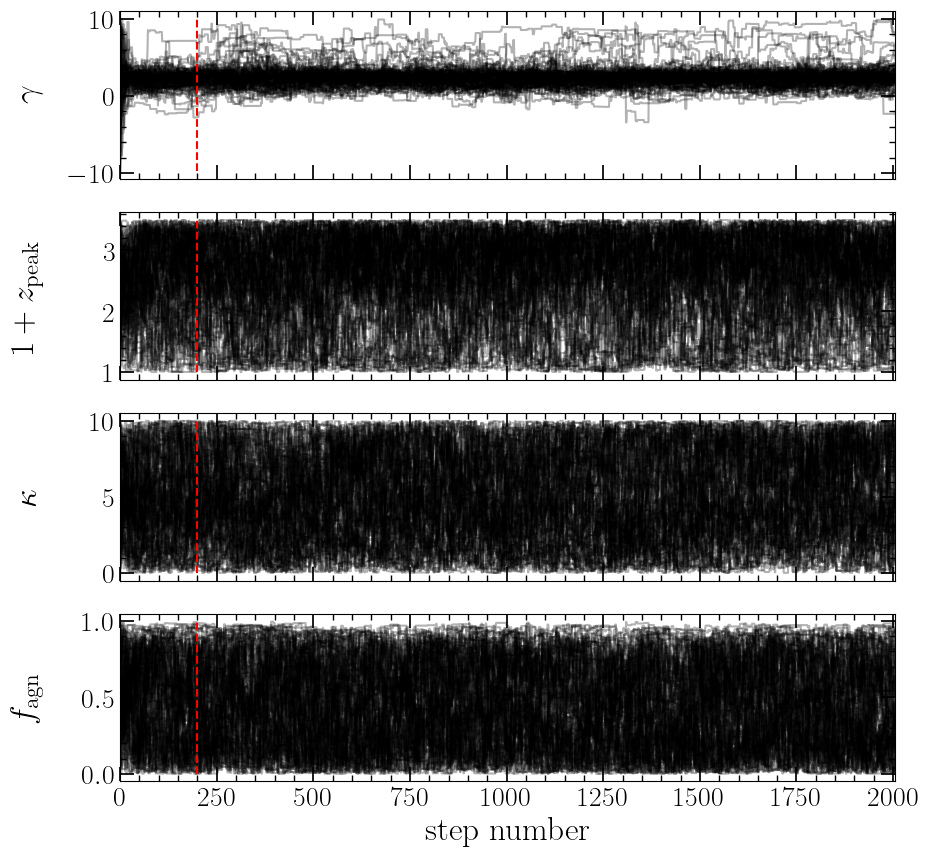

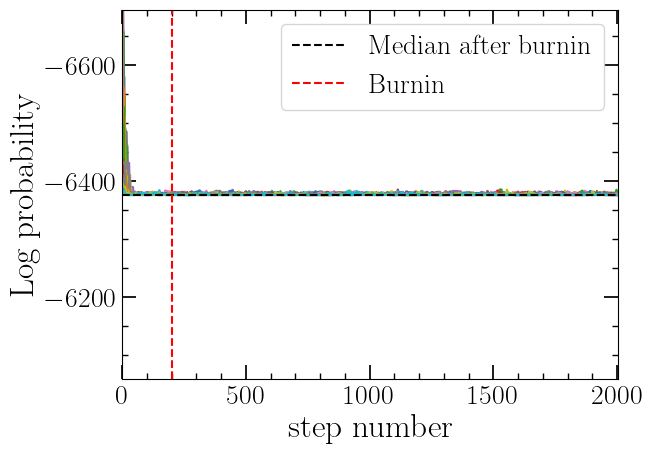

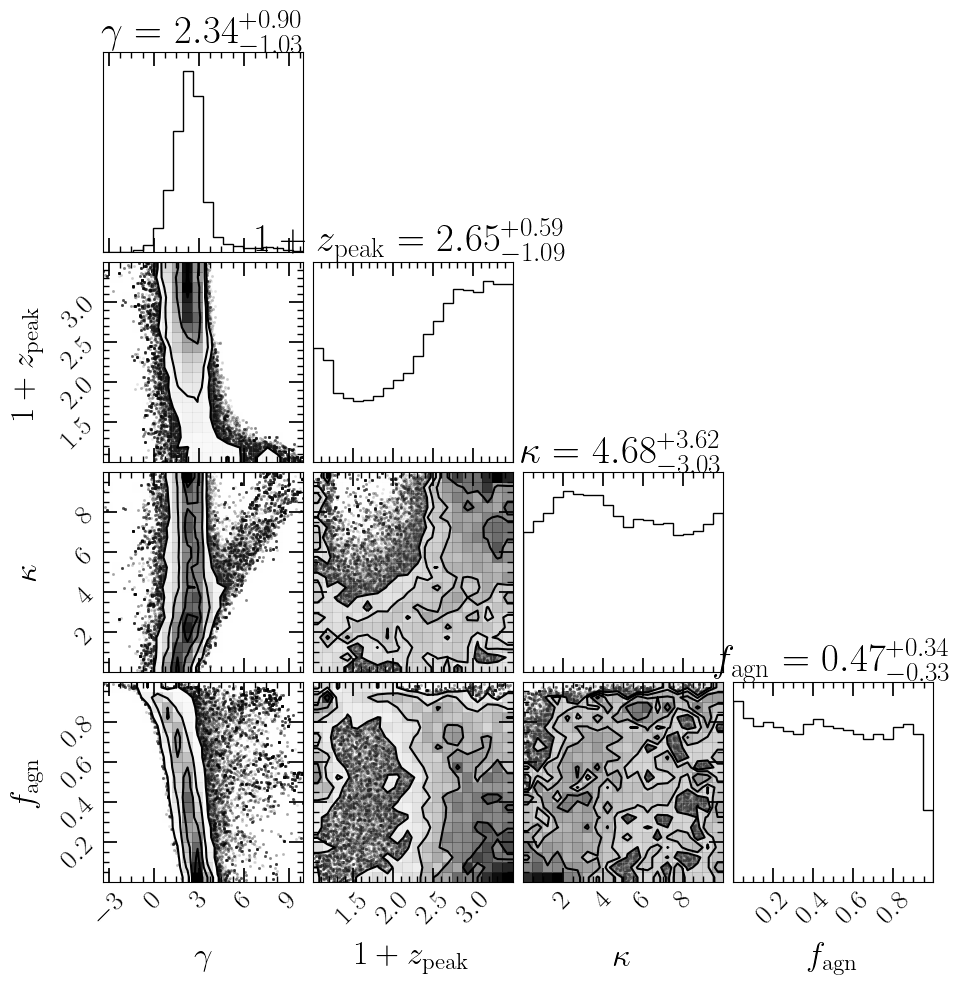

(162540,) (162540, 4)


In [10]:
filename = f"{HYPERPARAM_DIR}/sampler_uniform_priors_withcat_{LTHRESH_STRING}.h5"
backend = emcee.backends.HDFBackend(filename)
ndim=4

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend)

a_low = np.quantile(sampler.acceptance_fraction, 0.05)
a_high = np.quantile(sampler.acceptance_fraction, 0.95)
burnin = 200
print(a_low, a_high)

idx = []
get_diagnostics(sampler, ndim=ndim, burnin=burnin, acceptance_fraction_low=a_low, acceptance_fraction_high=a_high, remove_extra_walker_idx=idx)

good_walkers = np.where((sampler.acceptance_fraction >= a_low) & (sampler.acceptance_fraction <= a_high))[0]
samples = sampler.get_chain()
logprob = sampler.get_log_prob()
good_samples = samples[burnin:, good_walkers, :].reshape(-1, ndim)
good_logprob = logprob[burnin:, good_walkers].flatten()
print(good_logprob.shape, good_samples.shape)

# idx = []
# for i in range(100):
#     if i < 50:
#         continue
#     print(i)

#     get_diagnostics(sampler, burnin=burnin, acceptance_fraction_low=a_low, acceptance_fraction_high=a_high, remove_extra_walker_idx=[i])


In [11]:
# Nmodels_plot = 100
# randidx = np.random.choice(np.arange(good_samples.shape[0]), size=Nmodels_plot)
# b_post = good_samples[randidx, 0]
# c_post = good_samples[randidx, 1]
# d_post = good_samples[randidx, 2]
# fagn_post = good_samples[randidx, 3]
# try:
#     zmax_post = good_samples[randidx, 4]
# except IndexError:
#     zmax_post = np.tile(10, Nmodels_plot)

# zz = np.linspace(0, 10, 1024+1)
# # plt.figure()
# # for i in range(Nmodels_plot):
# #     model = time_dilation_correction(zz) * uniform_comoving_prior(zz) * merger_rate_madau_dickinson(zz, b_post[i], c_post[i], d_post[i]) * z_cut(zz, zcut=zmax_post[i])
# #     plt.plot(zz, model / romb(model, dx=np.diff(zz)[0]), color='skyblue', alpha=0.05)
# # # plt.loglog()
# # plt.ylim(0, 0.8)
# # plt.xlim(0, 3)
# # plt.show()

# plt.figure(figsize=(8,6))
# for i in range(Nmodels_plot):
#     alt_model = time_dilation_correction(zz) * uniform_comoving_prior(zz) * merger_rate_madau_dickinson(zz, b_post[i], c_post[i], d_post[i]) * z_cut(zz, zcut=zmax_post[i])
#     alt_model /= romb(alt_model, dx=np.diff(zz)[0])
#     agn_model = time_dilation_correction(zz) * get_agn_outofcat_pop('46.5', zmax=zmax_post[i])(zz)
#     agn_model /= romb(agn_model, dx=np.diff(zz)[0])
#     full_model = (1 - fagn_post[i]) * alt_model + fagn_post[i] * agn_model
    
#     plt.plot(zz, full_model, color='coral', alpha=0.05)
#     plt.plot(zz, alt_model, color='skyblue', alpha=0.05)
#     plt.plot(zz, agn_model, color='black', alpha=0.05)

# Nmodels_median = good_samples.shape[0] // 100
# full_models = np.zeros((Nmodels_median, len(zz)))
# alt_models = np.zeros((Nmodels_median, len(zz)))
# agn_models = np.zeros((Nmodels_median, len(zz)))
# randidx = np.random.choice(np.arange(good_samples.shape[0]), size=Nmodels_median)
# for i in range(Nmodels_median):
#     ix = randidx[i]
#     b_post = good_samples[ix, 0]
#     c_post = good_samples[ix, 1]
#     d_post = good_samples[ix, 2]
#     fagn_post = good_samples[ix, 3]
#     try:
#         zmax_post = good_samples[ix, 4]
#     except IndexError:
#         zmax_post = 10

#     alt_model = time_dilation_correction(zz) * uniform_comoving_prior(zz) * merger_rate_madau_dickinson(zz, b_post, c_post, d_post) * z_cut(zz, zcut=zmax_post)
#     alt_model /= romb(alt_model, dx=np.diff(zz)[0])
#     agn_model = time_dilation_correction(zz) * get_agn_outofcat_pop('46.5', zmax=zmax_post)(zz)
#     agn_model /= romb(agn_model, dx=np.diff(zz)[0])
#     full_model = (1 - fagn_post) * alt_model + fagn_post * agn_model

#     full_models[i,:] = full_model
#     alt_models[i,:] = alt_model
#     agn_models[i,:] = agn_model

# # plt.plot(zz, full_model, color='coral', alpha=1, label='full')
# # plt.plot(zz, alt_model, color='skyblue', alpha=1, label='alt')
# # plt.plot(zz, agn_model, color='black', alpha=1, label='agn')
# plt.plot(zz, np.median(full_models, axis=0), color='red', alpha=1, label='Full')
# plt.plot(zz, np.median(alt_models, axis=0), color='blue', alpha=1, label='Alternative')
# plt.plot(zz, np.median(agn_models, axis=0), color='black', alpha=1, label='AGN')

# LVK_models = np.zeros((len(df['gamma']), len(zz)))
# for k in range(len(df['gamma'])):
#     LVK_model = time_dilation_correction(zz) * uniform_comoving_prior(zz) * merger_rate_madau_dickinson(zz, df['gamma'].iloc[k], 1 + df['z_peak'].iloc[k], df['kappa'].iloc[k])# * z_cut(zz, zcut=zmax_post)
#     LVK_model /= romb(LVK_model, dx=np.diff(zz)[0])
#     LVK_models[k, :] = LVK_model
# plt.plot(zz, np.median(LVK_models, axis=0), color='green', alpha=1, label='LVK')

# # plt.loglog()
# # plt.ylim(0, 0.8)
# # plt.xlim(0, 1.5)
# plt.legend()
# plt.legend()
# plt.xlabel('Redshift')
# plt.ylabel(r'$p_{\rm pop}(z)$')
# plt.show()

# print(good_samples[np.argmax(good_logprob), 0], good_samples[np.argmax(good_logprob), 1], good_samples[np.argmax(good_logprob), 2], good_samples[np.argmax(good_logprob), 3])


In [12]:
def hdi(samples, cred_mass=0.9):
    """
    Highest Density Interval from posterior samples.

    Parameters
    ----------
    samples : array-like
        Posterior samples.
    cred_mass : float
        Desired probability mass (e.g. 0.9 for 90% HDI).

    Returns
    -------
    hdi_low, hdi_high
    """
    samples = np.asarray(samples)
    samples = np.sort(samples)

    n = len(samples)
    interval_idx = int(np.floor(cred_mass * n))

    if interval_idx < 1:
        raise ValueError("Not enough samples")

    widths = samples[interval_idx:] - samples[:n - interval_idx]
    min_idx = np.argmin(widths)

    return samples[min_idx], samples[min_idx + interval_idx]


[0.56944668 0.5705759  0.58251331 0.5705759  0.57364091 0.56234877
 0.56638167 0.57364091 0.56025165 0.57009195 0.56347798 0.57509276
 0.57864172 0.57105985 0.57864172 0.56557509 0.56573641 0.55460558
 0.55670269 0.5597677  0.55783191 0.57170511 0.58235199 0.56251008
 0.57541539 0.56186482 0.56638167 0.58251331 0.57283433 0.56847879
 0.57041458 0.55363768 0.56670431 0.5863849  0.57235038 0.57009195
 0.5557348  0.56121955 0.56605904 0.56912405 0.57622197 0.5626714
 0.56218745 0.57493144 0.56412325 0.56428456 0.56041297 0.57122116
 0.56299403 0.56009034 0.57283433 0.58090015 0.56251008 0.56718826
 0.57041458 0.56202613 0.56347798 0.56428456 0.58235199 0.55508953
 0.57428618 0.55444427 0.55734796 0.55944507 0.57235038 0.57364091
 0.56089692 0.55396032 0.56589773 0.57138248 0.5636393  0.56412325
 0.56783352 0.56686562 0.57799645 0.57186643 0.56218745 0.57509276
 0.56880142 0.56799484 0.56718826 0.57493144 0.57477012 0.56541378
 0.5597677  0.56428456 0.55847717 0.56976932 0.56412325 0.57089

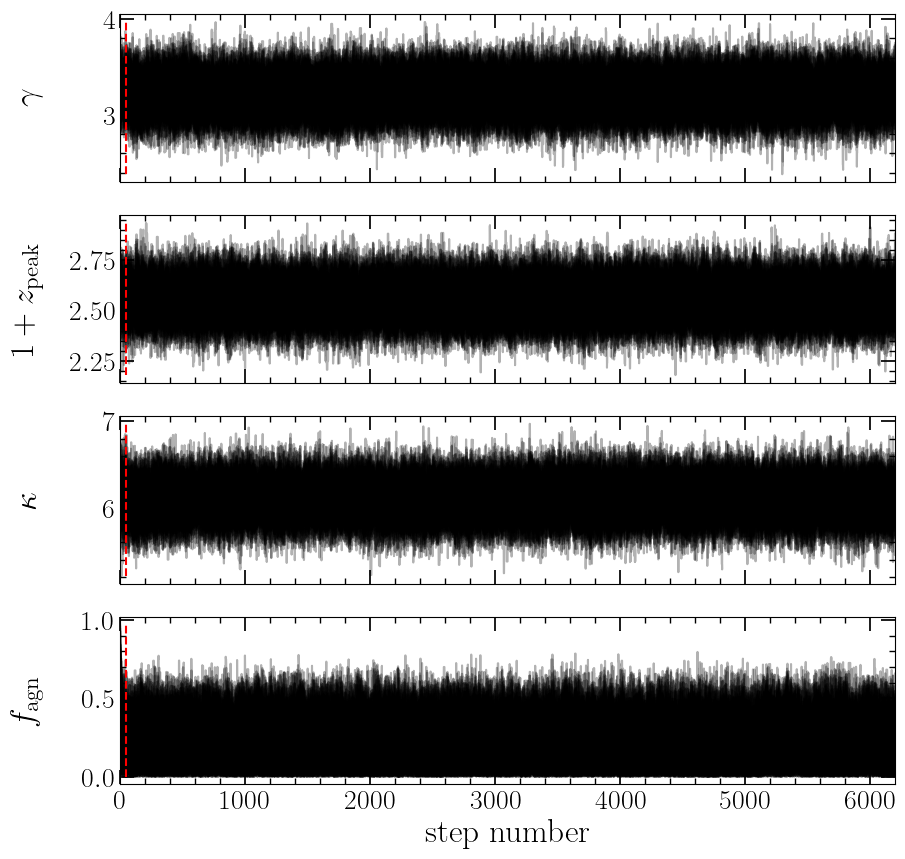

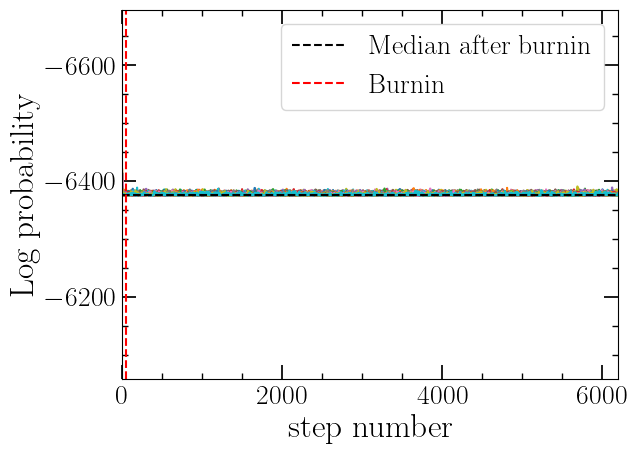

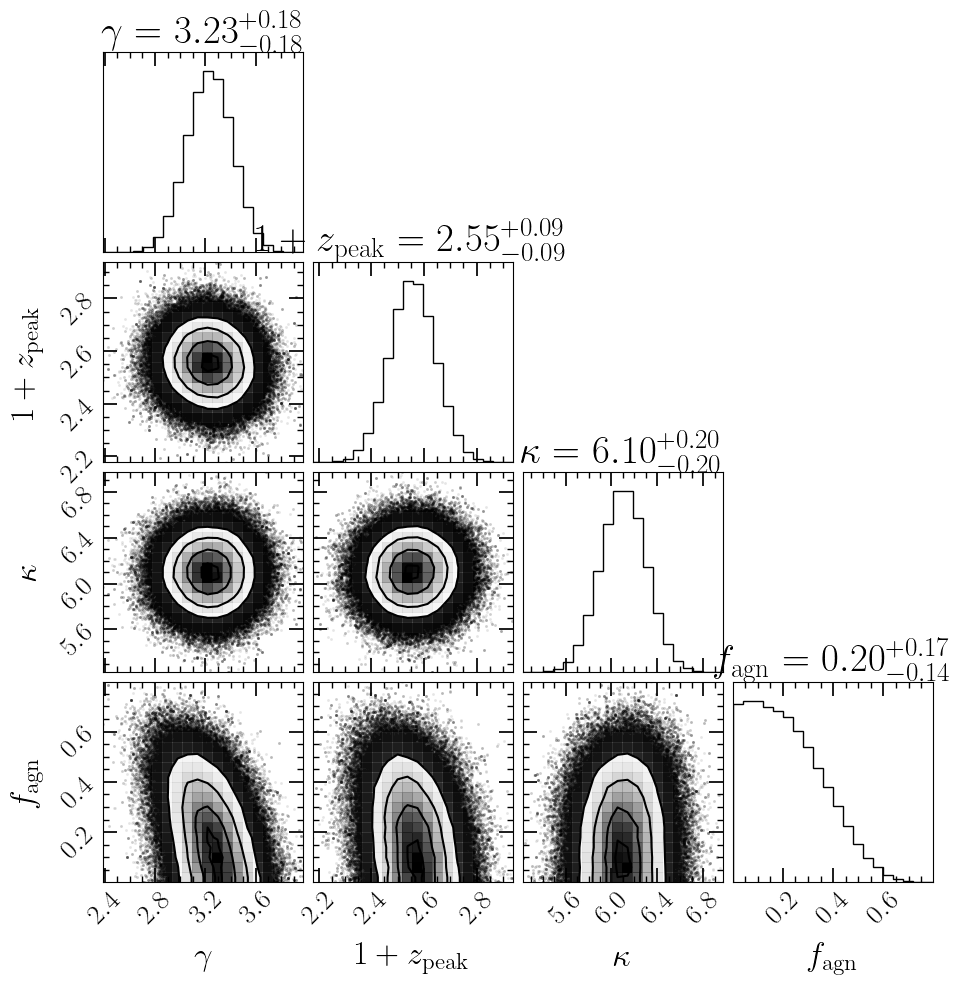

In [13]:
def get_clean_samples_from_backend(filename, nwalkers, ndim, burnin, a_low, a_high):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=emcee.backends.HDFBackend(filename))
    samples = sampler.get_chain()
    logprob = sampler.get_log_prob()

    good_walkers = np.where((sampler.acceptance_fraction >= a_low) & (sampler.acceptance_fraction <= a_high))[0]
    good_samples = samples[burnin:, good_walkers, :].reshape(-1, ndim)
    good_logprob = logprob[burnin:, good_walkers].flatten()

    get_diagnostics(sampler, burnin=burnin, acceptance_fraction_low=a_low, acceptance_fraction_high=a_high)
    return good_samples, good_logprob, sampler.acceptance_fraction

good_samples_gauss, good_logprob_gauss, _ = get_clean_samples_from_backend(f"{HYPERPARAM_DIR}/sampler_gauss_priors_withcat_{LTHRESH_STRING}.h5", nwalkers=100, ndim=4, burnin=50, a_low=0, a_high=1)


MAP Uniform prior:
b = 2.87
b = -1.11 - 9.92
c = 3.46
c = 1.00 - 3.50
d = 9.58
d = 0.00 - 10.00
fagn = 0.01
fagn = 0.00 - 0.99
MAP Gaussian prior:
b = 3.28
b = 2.75 - 3.77
c = 2.57
c = 2.33 - 2.80
d = 6.09
d = 5.56 - 6.63
fagn = 0.10
fagn = 0.00 - 0.63


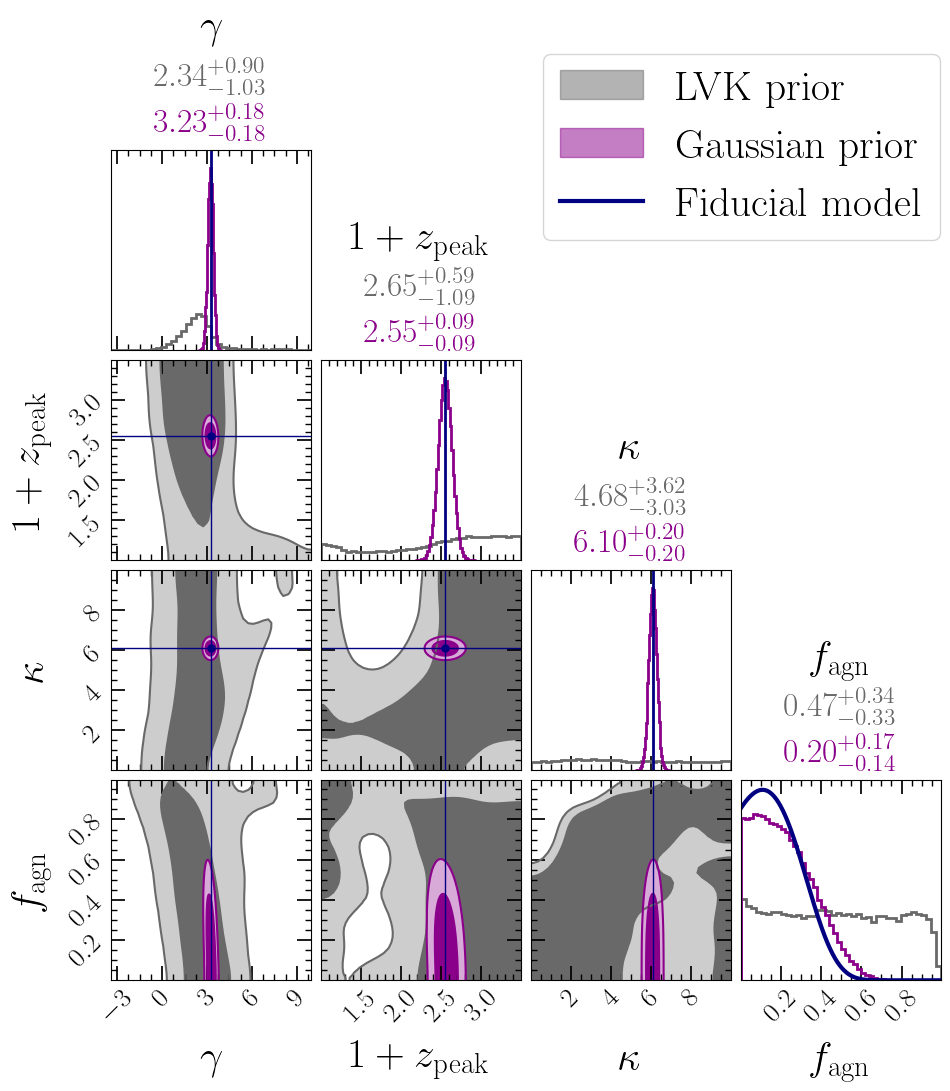

In [14]:
def get_cl_samps(logprob, samples, cl=0.9):
    idx = np.argsort(logprob)[::-1]
    cumprob = np.arange(1, len(logprob) + 1) / len(logprob)
    logprob_threshold = logprob[idx][np.searchsorted(cumprob, cl)]
    inside = logprob >= logprob_threshold
    return samples[inside]


medsize = 24
bigsize = 30
fixedcolors = {'44.5': 'orangered', '45.5': 'navy', '46.5': 'teal'}


labels = [f'{par_names_latex[i]}' for i in range(ndim)]

samples_1 = good_samples
logprob_1 = good_logprob
clsamps_1 = get_cl_samps(logprob_1, samples_1, cl=0.9)

samples_2 = good_samples_gauss
logprob_2 = good_logprob_gauss
clsamps_2 = get_cl_samps(logprob_2, samples_2, cl=0.9)

# # Optimal values (posterior medians)
# best_1 = np.median(samples_1, axis=0)
# best_2 = np.median(samples_2, axis=0)


best_1 = samples_1[np.argmax(logprob_1), :]
best_2 = samples_2[np.argmax(logprob_2), :]
print(f'MAP Uniform prior:')
for i, name in enumerate(par_names):
    print(f'{name} = {best_1[i]:.2f}')
    print(f'{name} = {np.min(clsamps_1[:, i]):.2f} - {np.max(clsamps_1[:, i]):.2f}')
print(f'MAP Gaussian prior:')
for i, name in enumerate(par_names):
    print(f'{name} = {best_2[i]:.2f}')
    print(f'{name} = {np.min(clsamps_2[:, i]):.2f} - {np.max(clsamps_2[:, i]):.2f}')

uniform_color = "dimgrey"
gauss_color = "darkmagenta"

fig = corner.corner(
    samples_1,
    labels=labels,
    label_kwargs={"fontsize": bigsize},
    color=uniform_color,
    bins=40,
    smooth=3.0,
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.68, 0.95),
    alpha=0.5,
    show_titles=False,
    hist_kwargs={"density": True, "linewidth": 2},
)

corner.corner(
    samples_2,
    fig=fig,
    labels=labels,
    label_kwargs={"fontsize": bigsize},
    color=gauss_color,
    bins=40,
    smooth=3.0,
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.68, 0.95),
    alpha=0.5,
    show_titles=False,
    hist_kwargs={"density": True, "linewidth": 2},
)

handles = [
    mpatches.Patch(facecolor=uniform_color, edgecolor=uniform_color,
                   alpha=0.5, label="LVK prior"),
    mpatches.Patch(facecolor=gauss_color, edgecolor=gauss_color,
                   alpha=0.5, label="Gaussian prior"),
    Line2D([0], [0], color=fixedcolors[LTHRESH_STRING], lw=3, label="Fiducial model"),
]

fig.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 1.08),
    frameon=True,
    fontsize=bigsize,
)

# Add best-fit markers
ndim = samples_1.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

best_1 = np.array([3.3, 2.55, 6.1])
for i in range(ndim):
    # 1D histograms
    if i < ndim - 1:
        axes[i, i].axvline(best_1[i], color=fixedcolors[LTHRESH_STRING], lw=2)
    # axes[i, i].axvline(best_2[i], color=f"{COLORS[0]}", lw=2)
    # axes[i, i].minorticks_off()

    # 2D panels
    for j in range(i):
        axes[i, j].axvline(best_1[j], color=fixedcolors[LTHRESH_STRING], lw=1)
        if (j < ndim - 1) & (i < ndim - 1):
            axes[i, j].axhline(best_1[i], color=fixedcolors[LTHRESH_STRING], lw=1)
            axes[i, j].plot(best_1[j], best_1[i], "o",
                            color=fixedcolors[LTHRESH_STRING], ms=5)

        # axes[i, j].axvline(best_2[j], color=fixedcolors[LTHRESH_STRING], lw=1)
        # axes[i, j].axhline(best_2[i], color=f"{COLORS[0]}", lw=1)
        # axes[i, j].plot(best_2[j], best_2[i], "o",
        #                 color=f"{COLORS[0]}", ms=5)

fixedpop_post = get_pdfs(corrected_log_llh_plot, axis=cfg_plot.LOG_LLH_X_AX)
axes[3, 3].plot(cfg_plot.LOG_LLH_X_AX, fixedpop_post, 
                color=fixedcolors[LTHRESH_STRING], linestyle='solid', linewidth=3)

axes[3, 3].set_ylim(0, 1.05 * np.max(fixedpop_post))
# axes[3, 3].hlines(1, 0, 1, color='black', linestyle='dashed')

q16_1, q50_1, q84_1 = np.percentile(samples_1, [16, 50, 84], axis=0)
q16_2, q50_2, q84_2 = np.percentile(samples_2, [16, 50, 84], axis=0)

ndim = samples_1.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))


for i in range(ndim):
    ax = axes[i, i]

    # remove corner's default title
    ax.set_title("")

    uniform_txt = (
        rf"${q50_1[i]:.2f}"
        rf"_{{-{q50_1[i]-q16_1[i]:.2f}}}"
        rf"^{{+{q84_1[i]-q50_1[i]:.2f}}}$"
    )

    gauss_txt = (
        rf"${q50_2[i]:.2f}"
        rf"_{{-{q50_2[i]-q16_2[i]:.2f}}}"
        rf"^{{+{q84_2[i]-q50_2[i]:.2f}}}$"
    )

    ax.text(
        0.5, 1.28, uniform_txt,
        transform=ax.transAxes,
        ha="center", va="bottom",
        color=uniform_color,
        fontsize=medsize,
    )

    ax.text(
        0.5, 1.05, gauss_txt,
        transform=ax.transAxes,
        ha="center", va="bottom",
        color=gauss_color,
        fontsize=medsize,
    )

    ax.text(0.5, 1.56, labels[i],
        transform=ax.transAxes,
        ha="center", fontsize=bigsize)

plt.savefig(f'{PLOT_DIR}/corner_{LTHRESH_STRING}.pdf', bbox_inches='tight')
plt.show()


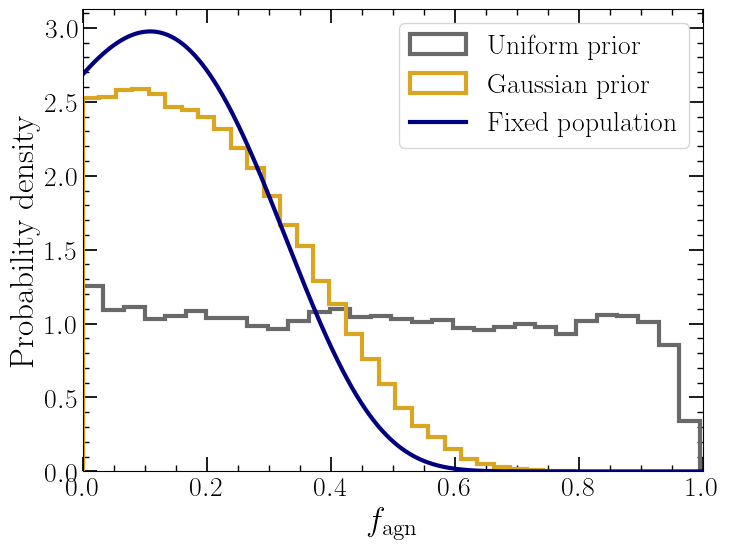

In [15]:
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(samples_1[:,3], histtype='step', bins=30, linewidth=3, color=uniform_color, density=True, label='Uniform prior')
ax.hist(samples_2[:,3], histtype='step', bins=30, linewidth=3, color='goldenrod', density=True, label='Gaussian prior')
ax.plot(cfg_plot.LOG_LLH_X_AX, fixedpop_post, color=fixedcolors[LTHRESH_STRING], linestyle='solid', linewidth=3, label='Fixed population')
ax.set_xlim(0, 1)
ax.set_xlabel(r'$f_{\rm agn}$')
ax.set_ylabel('Probability density')
ax.legend()
# plt.savefig(f'{PLOT_DIR}/fagn_priors_{LTHRESH_STRING}.pdf', bbox_inches='tight')
plt.show()


In [16]:
def hpd_1d(x, cl=0.9):
    x = np.sort(x)
    n = len(x)
    m = int(np.floor(cl * n))
    widths = x[m:] - x[:n-m]
    i = np.argmin(widths)
    return x[i], x[i+m]


def sample_pdf(pdf, eval_ax, nsamp):
    '''pdf must be evaluated on linear-spaced eval_ax'''
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]
    unif = np.random.rand(nsamp)
    return np.interp(unif, cdf, eval_ax)


N = int(1e7)
fagn_posterior = get_pdfs(corrected_log_llh_plot, axis=cfg_plot.LOG_LLH_X_AX)
fsamps = sample_pdf(fagn_posterior, cfg_plot.LOG_LLH_X_AX, N)
print(f'1D posterior rules out f_agn > {hpd_1d(fsamps)[1]:.3f} at 95% CL')
print(f'hyperposterior with uniform prior rules out f_agn > {hpd_1d(samples_1[:, 3])[1]:.3f} at 95% CL')
print(f'hyperposterior with Gaussian prior rules out f_agn > {hpd_1d(samples_2[:, 3])[1]:.3f} at 95% CL')
print()
print(f'Credible interval uniform prior: {hdi(good_samples[:, 3], cred_mass=0.95)}')
print(f'Credible interval Gaussian prior: {hdi(good_samples_gauss[:, 3], cred_mass=0.95)}')
print(f'Credible interval fixed prior: {hdi(fsamps, cred_mass=0.95)}')


1D posterior rules out f_agn > 0.358 at 95% CL
hyperposterior with uniform prior rules out f_agn > 0.870 at 95% CL
hyperposterior with Gaussian prior rules out f_agn > 0.420 at 95% CL

Credible interval uniform prior: (np.float64(0.007812810002587933), np.float64(0.9259990072187064))
Credible interval Gaussian prior: (np.float64(8.674809567899011e-07), np.float64(0.4782818044088827))
Credible interval fixed prior: (np.float64(0.0001), np.float64(0.4080467461791567))


In [ ]:
current = 0.28935 / 2
Ncurr = 256
need = 0.05
Nneed = (current / need)**2 * Ncurr
print(Nneed)


2143.3196159999998


# Posteriors on the rates

In [ ]:
def get_config(theta):
    b, c, d = theta
    rate_param_dict = {'b': b, 'c': c, 'd': d}

    cfg = Config()
    cfg.RATE_PARAMETERS = rate_param_dict
    cfg.VERBOSE = False
    cfg.THREADING = False
    cfg.REAL_DATA = True
    cfg.OUTFILE = 'none'
    cfg.AGN_DIST_DIR = '/home/lucas/Documents/PhD/generated_data/em'
    cfg.CATALOG_PATH = '/home/lucas/Documents/PhD/generated_data/em/quaia_zleq3_withlumcorr.csv'  # '/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv'
    cfg.CMAP_PATH = '/home/lucas/Documents/PhD/completeness_map.fits'
    cfg.ZMIN = 0.000001
    cfg.ZMAX = 10
    cfg.AGN_ZMAX = 10
    cfg.AGN_ZCUT = 3.0
    cfg.AGN_ZPRIOR = LTHRESH_STRING
    cfg.LUM_THRESH = LTHRESH_STRING
    cfg.MASK_GALACTIC_PLANE = True
    cfg.ASSUME_PERFECT_REDSHIFT = False
    cfg.AGN_ZERROR = 'quaia'
    cfg.CORRECT_TIME_DILATION = True
    cfg.MERGER_RATE = 'madau'
    cfg.LABEL = 'samplinggwtc5'
    cfg.finalize()

    return cfg

cfg = get_config(theta=np.array([3.3, 2.55, 6.1]))
agn_posterior_dset, agn_ra, agn_dec, obs_agn_redshift, redshift_completeness = load_quaia(0, cfg)
average_completeness, average_redshift_completeness, sky_coverage, fc_of_z, p_rate_of_z_agn, p_rate_of_z_alt, p_rate_of_z_agn_func, PEprior, PEprior_func, normed_agn_background_dist, fc_and_rate_weighted_agn_background_dist, jacobian, dz = prepare_functions(cfg, redshift_completeness)
sum_of_all_agn_posteriors = np.sum(agn_posterior_dset, axis=0)
nagn_norm = romb(sum_of_all_agn_posteriors, dx=dz)

if nagn_norm == 0:
    agn_redshift_population_prior = fc_and_rate_weighted_agn_background_dist
else:
    agn_redshift_population_prior = p_rate_of_z_agn * average_redshift_completeness * sum_of_all_agn_posteriors / nagn_norm + fc_and_rate_weighted_agn_background_dist
agn_redshift_population_prior /= romb(agn_redshift_population_prior * jacobian, dx=dz)

background_alt_distribution = uniform_comoving_prior(cfg.Z_INTEGRAL_AX, cosmo=cfg.COSMO)
alt_redshift_population_prior = background_alt_distribution * p_rate_of_z_alt
alt_redshift_population_prior /= romb(alt_redshift_population_prior * jacobian, dx=dz)


In [ ]:
filename = "/home/lucas/Documents/PhD/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5"
result_MD = PopulationResult(fname=filename)

md_bbh_z_grid, md_bb_Rz = result_MD.get_rates_on_grids('redshift')
md_bbh_z_grid = md_bbh_z_grid.reshape((md_bbh_z_grid.size, ))

# rate_LVK = result.get_hyperparameter_samples(hyperparameters=['rate']).squeeze()  # 1/Gpc^3 1/year

# # REDSHIFT
# # lamb = result.get_hyperparameter_samples(hyperparameters=['lamb'])
# kappa = result.get_hyperparameter_samples(hyperparameters=['kappa']).squeeze()
# gamma = result.get_hyperparameter_samples(hyperparameters=['gamma']).squeeze()
# z_peak = result.get_hyperparameter_samples(hyperparameters=['z_peak']).squeeze()

# # SPIN
# mu_chi = result.get_hyperparameter_samples(hyperparameters=['mu_chi']).squeeze()
# sigma_chi = result.get_hyperparameter_samples(hyperparameters=['sigma_chi']).squeeze()
# mu_spin = result.get_hyperparameter_samples(hyperparameters=['mu_spin']).squeeze()
# sigma_spin = result.get_hyperparameter_samples(hyperparameters=['sigma_spin']).squeeze()
# xi_spin = result.get_hyperparameter_samples(hyperparameters=['xi_spin']).squeeze()

# # MASS
# alpha_1 = result.get_hyperparameter_samples(hyperparameters=['alpha_1']).squeeze()
# alpha_2 = result.get_hyperparameter_samples(hyperparameters=['alpha_2']).squeeze()
# break_mass = result.get_hyperparameter_samples(hyperparameters=['break_mass']).squeeze()
# mpp_1 = result.get_hyperparameter_samples(hyperparameters=['mpp_1']).squeeze()
# sigpp_1 = result.get_hyperparameter_samples(hyperparameters=['sigpp_1']).squeeze()
# mpp_2 = result.get_hyperparameter_samples(hyperparameters=['mpp_2']).squeeze()
# sigpp_2 = result.get_hyperparameter_samples(hyperparameters=['sigpp_2']).squeeze()
# mlow_1 = result.get_hyperparameter_samples(hyperparameters=['mlow_1']).squeeze()
# delta_m_1 = result.get_hyperparameter_samples(hyperparameters=['delta_m_1']).squeeze()
# lam_0 = result.get_hyperparameter_samples(hyperparameters=['lam_0']).squeeze()
# lam_1 = result.get_hyperparameter_samples(hyperparameters=['lam_1']).squeeze()
# mmax = result.get_hyperparameter_samples(hyperparameters=['mmax']).squeeze()
# beta = result.get_hyperparameter_samples(hyperparameters=['beta']).squeeze()
# mlow_2 = result.get_hyperparameter_samples(hyperparameters=['mlow_2']).squeeze()
# delta_m_2 = result.get_hyperparameter_samples(hyperparameters=['delta_m_2']).squeeze()

# b = (break_mass - mlow_1) / (mmax - mlow_1)
# lambda_g = 1 - lam_0
# lambda_g_0 = lam_1 / lambda_g


creating a new popsummary file: /home/lucas/Documents/PhD/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = '/home/lucas/Documents/PhD/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

In [ ]:
# SELECTION EFFECTS
N_det = 256
far_thr = 1
snr_thr = 10
sel = ((snr_inject > snr_thr) | (far_inject < far_thr))

z_sel = redshift_inject[sel]
m1s_sel = mass1_source_inject[sel]
m2s_sel = mass2_source_inject[sel]
cost1_sel = np.cos(spin1theta[sel])
cost2_sel = np.cos(spin2theta[sel])
spin1r_sel = spin1r[sel]
spin2r_sel = spin2r[sel]
spin1phi_sel = spin1phi[sel]
spin2phi_sel = spin2phi[sel]

lnspin_sel = spinpop_MAP(spin1phi_sel, spin2phi_sel, spin1r_sel, spin2r_sel, cost1_sel, cost2_sel)
lnm1m2_sel = masspop_MAP.log_joint_prob(m1s_sel, m2s_sel).detach().cpu().numpy()

z_int_ax = np.linspace(1e-6, 10, 1024+1)
dz = np.diff(z_int_ax)[0]
dVc_dz = lambda z: COSMO.differential_comoving_volume(z).to(u.Gpc**3 / u.sr).value * 4 * np.pi / (1 + z)  # Compensated for time dilation
dVc_dz_intax = dVc_dz(z_int_ax)
dVc_dz_sel = dVc_dz(z_sel)

lnz_vol_sel = np.log(dVc_dz_sel)
w_sel = weights[sel]
lnprob_sel = lnprob[sel]

Tyr = (total_analysis_time * u.s).to(u.year).value

# def lnz_pdf(z, lamb):
#     unnorm = COSMO.differential_comoving_volume(z).to(u.Gpc**3 / u.sr).value * 4 * np.pi / (1 + z) * (1 + z)**lamb
#     unnorm_interp = interp1d(z, unnorm, fill_value=0, bounds_error=False)
#     normax = np.linspace(0, 10, 1024+1)
#     return unnorm_interp(z) / romb(unnorm_interp(normax), dx=np.diff(normax)[0])



In [ ]:
z_int_ax = np.linspace(1e-6, 10, 1024+1)
dz = np.diff(z_int_ax)[0]
dVc_dz = lambda z: COSMO.differential_comoving_volume(z).to(u.Gpc**3 / u.sr).value * 4 * np.pi / (1 + z)  # Compensated for time dilation
dVc_dz_intax = dVc_dz(z_int_ax)

unif_src_eval = uniform_source_frame(cfg.Z_INTEGRAL_AX)  # Not normalized, values in Mpc**3, but constants divide out
log_unif_src_sel = np.log(uniform_source_frame(z_sel))

def local_rate_density(zpop_func):
    '''Units given by lnz_vol_sel, I use Gpc^-3 yr^-1'''
    lnz_pop_sel = np.log(zpop_func(z_sel)) - log_unif_src_sel
    E_i = np.random.gamma(shape=N_det, scale=1.0)
    lnp_sel = lnm1m2_sel + lnspin_sel + lnz_vol_sel + lnz_pop_sel  # lnz_vol_sel is what provides the units
    MC_sum = np.sum( w_sel * np.exp(lnp_sel - lnprob_sel) ) / total_generated
    R_0 = E_i / Tyr / (MC_sum)
    return R_0


f26 = lambda z: 0.51*(1 + z)**4.31

eval_f26 = 1.0  # Redshift at which to match the Farah+26 population
f26_at_z = f26(eval_f26)


def pop2rate(fagn, agn_zpop, alt_zpop, eval_f26=eval_f26):
    '''
    We require p(z) \propto dV/dz (1+z)^{-1}
    Therefore, we factorize dV/dz (1+z)^{-1} * [ agn_zpop * fagn + alt_zpop * (1 - fagn) ] / ( dV/dz (1+z)^{-1} )

    R(z) = R_0 dV/dz 1/(1+z) psi(z)
    '''

    zpop_eval = agn_zpop * fagn + alt_zpop * (1 - fagn)
    zpop_interp = CubicSpline(cfg.Z_INTEGRAL_AX, zpop_eval, extrapolate=False)
    R_0_full = local_rate_density(zpop_interp)
    R_z_full = R_0_full * zpop_eval / unif_src_eval
    total_rate_full = romb(R_z_full * dVc_dz_intax, dx=dz)

    psi_z_alt = alt_zpop / unif_src_eval
    psi_z_agn = agn_zpop / unif_src_eval

    I_alt = romb(psi_z_alt * dVc_dz_intax, dx=dz)
    I_agn = romb(psi_z_agn * dVc_dz_intax, dx=dz)

    R_0_alt = (1 - fagn) * total_rate_full / I_alt
    R_0_agn = fagn * total_rate_full / I_agn

    R_z_alt = R_0_alt * psi_z_alt
    R_z_agn = R_0_agn * psi_z_agn

    fagn_for_f26_at_z = f26_at_z / (total_rate_full / I_agn * CubicSpline(cfg.Z_INTEGRAL_AX, psi_z_agn, extrapolate=False)(eval_f26))
    
    return R_z_full, R_z_alt, R_z_agn, fagn_for_f26_at_z


<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_366650/3054332451.py:27: SyntaxWarning: invalid escape sequence '\p'
  We require p(z) \propto dV/dz (1+z)^{-1}


[3.85247794 4.12680339] [0.04852669 0.02113918]


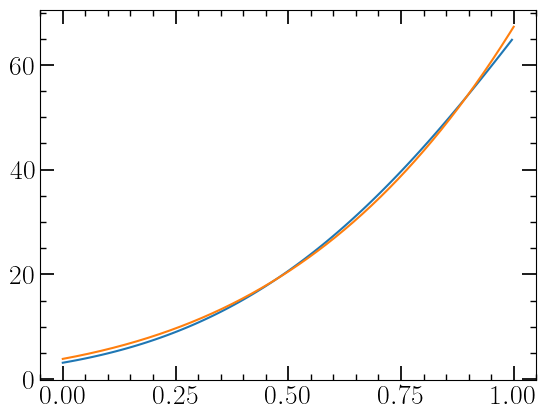

Rate evolution powerlaw index below z = 1.0 for 44.5: 4.13 +/- 0.02


In [ ]:
xdat = cfg.Z_INTEGRAL_AX[:np.where(cfg.Z_INTEGRAL_AX >= eval_f26)[0][0]]
ydat = (1e13 * normed_agn_background_dist * p_rate_of_z_agn / unif_src_eval)[:np.where(cfg.Z_INTEGRAL_AX >= eval_f26)[0][0]]

def powerlaw(z, a, b):
    return a * (1 + z)**b

p, c = curve_fit(powerlaw, xdat, ydat)
print(p, np.sqrt(np.diag(c)))

xx = np.linspace(0, eval_f26, 1000)

plt.figure()
plt.plot(xdat, ydat)
plt.plot(xx, powerlaw(xx, *p))
plt.show()

print(f'Rate evolution powerlaw index below z = {eval_f26} for {LTHRESH_STRING}: {p[1]:.2f} +/- {np.sqrt(np.diag(c))[1]:.2f}')


In [ ]:
N = int(1000)
fagn_posterior = get_pdfs(corrected_log_llh_plot, axis=cfg_plot.LOG_LLH_X_AX)
fsamps = sample_pdf(fagn_posterior, cfg_plot.LOG_LLH_X_AX, N)

zpop_posts = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
rates = np.zeros(N)
zpop_posts_agn = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
rates_agn = np.zeros(N)
zpop_posts_alt = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
rates_alt = np.zeros(N)

zpop_posts_samp = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
rates_samp = np.zeros(N)
zpop_posts_samp_agn = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
rates_samp_agn = np.zeros(N)
zpop_posts_samp_alt = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
rates_samp_alt = np.zeros(N)

R_z_full_arr = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
R_z_alt_arr = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
R_z_agn_arr = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
fagn_f26_arr = np.zeros(N)

randidx = np.random.choice(np.arange(good_samples.shape[0]), size=N)
for i, (b, c, d, fagn) in tqdm( enumerate(zip(good_samples[randidx, 0],
                                              good_samples[randidx, 1],
                                              good_samples[randidx, 2],
                                              good_samples[randidx, 3])), total=N ):

    # My own zpops
    # alt_zpop_samp = get_alt_pop(zmax=10, rate_model='madau', rate_parameters={'b': b, 'c': c, 'd': d})(cfg.Z_INTEGRAL_AX)
    # R_z_full, R_z_alt, R_z_agn, fagn_for_f26_at_z = pop2rate(fagn, agn_zpop=agn_redshift_population_prior, alt_zpop=alt_zpop_samp)

    R_z_full, R_z_alt, R_z_agn, fagn_for_f26_at_z = pop2rate(fsamps[i], agn_zpop=agn_redshift_population_prior, alt_zpop=alt_redshift_population_prior, eval_f26=eval_f26)

    
    R_z_full_arr[i,:] = R_z_full
    R_z_alt_arr[i,:] = R_z_alt
    R_z_agn_arr[i,:] = R_z_agn

    fagn_f26_arr[i] = fagn_for_f26_at_z


100%|██████████| 1000/1000 [00:54<00:00, 18.51it/s]


In [ ]:
med = np.quantile(fagn_f26_arr, 0.5)
print(f'To match the Farah+26 hierarchical subpopulation rate at z=1.5, we need fagn = {med:.3f}^+{np.quantile(fagn_f26_arr, 0.84) - med:.3f}_-{med - np.quantile(fagn_f26_arr, 0.16):.3f} for AGN brighter than 10^{LTHRESH_STRING}')



To match the Farah+26 hierarchical subpopulation rate at z=1.5, we need fagn = 0.076^+0.007_-0.007 for AGN brighter than 10^44.5


In [ ]:
def get_config_lum(theta, lum):
    b, c, d = theta
    rate_param_dict = {'b': b, 'c': c, 'd': d}

    cfg = Config()
    cfg.RATE_PARAMETERS = rate_param_dict
    cfg.VERBOSE = False
    cfg.THREADING = False
    cfg.REAL_DATA = True
    cfg.OUTFILE = 'none'
    cfg.AGN_DIST_DIR = '/home/lucas/Documents/PhD/generated_data/em'
    cfg.CATALOG_PATH = '/home/lucas/Documents/PhD/generated_data/em/quaia_zleq3_withlumcorr.csv'  # '/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv'
    cfg.CMAP_PATH = '/home/lucas/Documents/PhD/completeness_map.fits'
    cfg.ZMIN = 0.000001
    cfg.ZMAX = 10
    cfg.AGN_ZMAX = 10
    cfg.AGN_ZCUT = 3.0
    cfg.AGN_ZPRIOR = lum
    cfg.LUM_THRESH = lum
    cfg.MASK_GALACTIC_PLANE = True
    cfg.ASSUME_PERFECT_REDSHIFT = False
    cfg.AGN_ZERROR = 'quaia'
    cfg.CORRECT_TIME_DILATION = True
    cfg.MERGER_RATE = 'madau'
    cfg.LABEL = 'samplinggwtc5'
    cfg.finalize()

    return cfg


def get_agn_zprior(lum):
    cfg = get_config_lum(theta=np.array([3.3, 2.55, 6.1]), lum=lum)
    agn_posterior_dset, agn_ra, agn_dec, obs_agn_redshift, redshift_completeness = load_quaia(0, cfg)
    average_completeness, average_redshift_completeness, sky_coverage, fc_of_z, p_rate_of_z_agn, p_rate_of_z_alt, p_rate_of_z_agn_func, PEprior, PEprior_func, normed_agn_background_dist, fc_and_rate_weighted_agn_background_dist, jacobian, dz = prepare_functions(cfg, redshift_completeness)
    sum_of_all_agn_posteriors = np.sum(agn_posterior_dset, axis=0)
    nagn_norm = romb(sum_of_all_agn_posteriors, dx=dz)

    if nagn_norm == 0:
        agn_redshift_population_prior = fc_and_rate_weighted_agn_background_dist
    else:
        agn_redshift_population_prior = p_rate_of_z_agn * average_redshift_completeness * sum_of_all_agn_posteriors / nagn_norm + fc_and_rate_weighted_agn_background_dist
    agn_redshift_population_prior /= romb(agn_redshift_population_prior * jacobian, dx=dz)
    return agn_redshift_population_prior


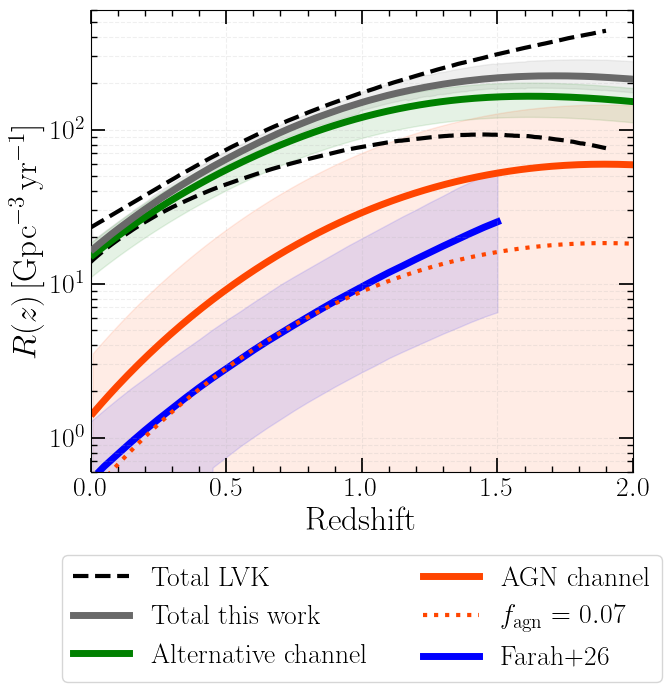

In [ ]:
plt.figure(figsize=(7,6))

alpha_contour = 0.5
alpha_fill = 0.1
Nplot = 100

plt.plot(md_bbh_z_grid, np.quantile(md_bb_Rz, 0.05, axis = 0), linestyle='dashed', color='black', alpha=1, zorder=10, linewidth=3, label='Total LVK')
plt.plot(md_bbh_z_grid, np.quantile(md_bb_Rz, 0.95, axis = 0), linestyle='dashed', color='black', alpha=1, zorder=10, linewidth=3)

plt.plot(cfg.Z_INTEGRAL_AX[1:], np.median(R_z_full_arr, axis=0)[1:], linestyle='solid', color='dimgrey', alpha=1, linewidth=5, zorder=15, label='Total this work')
# plt.plot(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_full_arr, 0.05, axis=0)[1:], linestyle='dashed', color='blue', alpha=1, linewidth=3, zorder=10)
# plt.plot(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_full_arr, 0.95, axis=0)[1:], linestyle='dashed', color='blue', alpha=1, linewidth=3, zorder=10)

lower_Rfull = np.zeros(R_z_full_arr.shape[1])
upper_Rfull = np.zeros(R_z_full_arr.shape[1])
for i in range(R_z_full_arr.shape[1]):
      lower_Rfull[i], upper_Rfull[i] = hdi(R_z_full_arr[:,i], cred_mass=0.9)
plt.fill_between(cfg.Z_INTEGRAL_AX, lower_Rfull, upper_Rfull, color='dimgrey', alpha=alpha_fill)
# plt.fill_between(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_full_arr, 0.05, axis=0)[1:], np.quantile(R_z_full_arr, 0.95, axis=0)[1:], color='dimgrey', alpha=alpha_fill, zorder=14)

plt.plot(cfg.Z_INTEGRAL_AX[1:], np.median(R_z_alt_arr, axis=0)[1:], linestyle='solid', color='green', alpha=1, linewidth=5, zorder=10, label='Alternative channel')
# plt.plot(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_alt_arr, 0.05, axis=0)[1:], linestyle='dashed', color='red', alpha=alpha_contour, linewidth=3, zorder=10)
# plt.plot(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_alt_arr, 0.95, axis=0)[1:], linestyle='dashed', color='red', alpha=alpha_contour, linewidth=3, zorder=10)
# for i in range(Nplot):
#     plt.plot(cfg.Z_INTEGRAL_AX, R_z_alt_arr[i,:], linestyle='solid', color='red', linewidth=1, alpha=0.1)

lower_Rzalt = np.zeros(R_z_alt_arr.shape[1])
upper_Rzalt = np.zeros(R_z_alt_arr.shape[1])
for i in range(R_z_alt_arr.shape[1]):
      lower_Rzalt[i], upper_Rzalt[i] = hdi(R_z_alt_arr[:,i], cred_mass=0.9)
plt.fill_between(cfg.Z_INTEGRAL_AX, lower_Rzalt, upper_Rzalt, color='green', alpha=alpha_fill)
# plt.fill_between(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_alt_arr, 0.05, axis=0)[1:], np.quantile(R_z_alt_arr, 0.95, axis=0)[1:], color='green', alpha=alpha_fill)

plt.plot(cfg.Z_INTEGRAL_AX[1:], np.median(R_z_agn_arr, axis=0)[1:], linestyle='solid', color='orangered', alpha=1, linewidth=5, label='AGN channel')
# plt.plot(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_agn_arr, 0.05, axis=0)[1:], linestyle='dashed', color='green', alpha=alpha_contour, linewidth=3)
# plt.plot(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_agn_arr, 0.95, axis=0)[1:], linestyle='dashed', color='green', alpha=alpha_contour, linewidth=3)

lower_Rzagn = np.zeros(R_z_agn_arr.shape[1])
upper_Rzagn = np.zeros(R_z_agn_arr.shape[1])
for i in range(R_z_agn_arr.shape[1]):
      lower_Rzagn[i], upper_Rzagn[i] = hdi(R_z_agn_arr[:,i], cred_mass=0.9)
plt.fill_between(cfg.Z_INTEGRAL_AX[1:], lower_Rzagn[1:], upper_Rzagn[1:], color='orangered', alpha=alpha_fill)


# plt.fill_between(cfg.Z_INTEGRAL_AX[1:], np.quantile(R_z_agn_arr, 0.05, axis=0)[1:], np.quantile(R_z_agn_arr, 0.95, axis=0)[1:], color='green', alpha=alpha_fill)
# for i in range(Nplot):
#     plt.plot(cfg.Z_INTEGRAL_AX, R_z_agn_arr[i,:], linestyle='solid', color='teal', linewidth=1, alpha=0.1)

# plt.plot(cfg.Z_INTEGRAL_AX, 19*(1 + cfg.Z_INTEGRAL_AX)**2.31, color='black', linestyle='solid', label='Farah+26', linewidth=5)

# agn_zpop_46p5 = get_agn_zprior('46.5') / unif_src_eval
# plt.plot(cfg.Z_INTEGRAL_AX, agn_zpop_46p5 * farah26[154] / agn_zpop_46p5[154])
# agn_zpop_45p5 = get_agn_zprior('45.5') / unif_src_eval
# plt.plot(cfg.Z_INTEGRAL_AX, agn_zpop_45p5 * farah26[154] / agn_zpop_45p5[154])
# agn_zpop_44p5 = get_agn_zprior('44.5') / unif_src_eval
# plt.plot(cfg.Z_INTEGRAL_AX, agn_zpop_44p5 * farah26[154] / agn_zpop_44p5[154])

# plt.plot(cfg.Z_INTEGRAL_AX, 1e13 * normed_agn_background_dist * p_rate_of_z_agn / unif_src_eval, color='hotpink')

# psi = agn_zpop_44p5
# prediction = np.quantile(fagn_f26_arr, 0.5) * np.median( romb(R_z_full * dVc_dz_intax, dx=dz, axis=0) ) / romb(psi * dVc_dz_intax, dx=dz)
# plt.plot(cfg.Z_INTEGRAL_AX, psi * prediction, color='hotpink')

_, _, R_z_agn_f26match, _ = pop2rate(0.07, agn_zpop=agn_redshift_population_prior, alt_zpop=alt_redshift_population_prior, eval_f26=eval_f26)
plt.plot(cfg.Z_INTEGRAL_AX[1:], R_z_agn_f26match[1:], linestyle='dotted', color='orangered', linewidth=3, label=r'$f_{\rm agn} = 0.07$')

# farah26 = 0.51*(1 + cfg.Z_INTEGRAL_AX)**4.31
# plt.plot(cfg.Z_INTEGRAL_AX, farah26, color='black', linestyle='solid', label='Farah+26', linewidth=5, zorder=1)

# plt.fill_between(cfg.Z_INTEGRAL_AX, 0.1*(1 + cfg.Z_INTEGRAL_AX)**(4.31 - 0.75), 1.275*(1 + cfg.Z_INTEGRAL_AX)**(4.31 + 0.72), color='black', alpha=alpha_fill)

# f = '/home/lucas/Documents/plot-data.csv'
# d = pd.read_csv(f)
# plt.plot(d.loc[d.keys()[0]][:], d.loc[d.keys()[1]][:])

x1 = [0.00,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,
      0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00,
      1.05,1.10,1.15,1.20,1.25,1.30,1.35,1.40,1.45,1.50]

y1 = [1.274, 1.512,1.786,2.095,2.431,2.831,3.273,3.770,4.343,5.039,5.784,
      6.590,7.564,8.619,9.856,11.109,12.476,14.011,15.734,17.670,19.701,
      21.965,24.489,27.304,30.221,33.695,37.295,41.581,45.692,50.210, 54.33]

y3 = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.640,0.748,0.874,1.007,1.156,1.317,1.501,1.698,1.907,2.141,
      2.388,2.662,2.946,3.285,3.610,3.952,4.327,4.738,5.150,5.618,6.085,6.529]


x2 = [0.0335,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,
      0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00,
      1.05,1.10,1.15,1.20,1.25,1.30,1.35,1.40,1.45,1.50]

y2 = [0.607, 0.650,0.781,0.937,1.115,1.317,1.545,1.812,2.111,2.440,2.801,
      3.214,3.689,4.204,4.755,5.379,6.063,6.834,7.674,8.556,9.540,
      10.636,11.815,13.030,14.423,15.907,17.543,19.277,21.183,23.193,25.198]



plt.fill_between(x1, y1, y3, color='blue', alpha=alpha_fill)
plt.plot(x2, y2, color='blue', linestyle='solid', label='Farah+26', linewidth=5, zorder=1)

plt.ylabel(r'$R(z) \, [\mathrm{Gpc^{-3} \, yr^{-1}}]$')
plt.xlabel('Redshift')
plt.xlim(0, 2)
plt.ylim(0.6, 6e2)
plt.semilogy()
plt.grid(alpha=0.2, which='minor', linestyle='dashed', axis='y')
plt.grid(alpha=0.2, which='major', linestyle='dashed', axis='both')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)
# plt.savefig(f'/home/lucas/Documents/PhD/darksirenpop/p26plots_v2/rates_{LTHRESH_STRING}.pdf', bbox_inches='tight')
plt.show()


In [ ]:
def get_alt_evidence(theta):    
    cfg = get_config(theta)

    with open(cfg.JSON_PATH, "r") as f:
        gw_path_dict = json.load(f)
    gw_keys = list(gw_path_dict.keys())
    gw_fnames = [gw_path_dict[key] for key in gw_keys]

    ### Prepare functions for in the likelihood ###
    if cfg.CORRECT_TIME_DILATION:
        time_dilation_func = lambda z: time_dilation_correction(z)
    else: 
        time_dilation_func = lambda z: np.ones_like(z)
    time_dilation = time_dilation_func(cfg.Z_INTEGRAL_AX)
    zcut = z_cut(cfg.Z_INTEGRAL_AX, zcut=cfg.ZMAX)
    zrate_alt = merger_rate(cfg.Z_INTEGRAL_AX, cfg.MERGER_RATE_EVOLUTION, **cfg.MERGER_RATE_KWARGS)
    p_rate_of_z_alt = time_dilation * zrate_alt * zcut
    PEprior_func = lambda z: uniform_comoving_prior(z, cosmo=cfg.COSMO)
    PEprior = PEprior_func(cfg.Z_INTEGRAL_AX)
    dz, jacobian = get_dz_and_jacobian(cfg)

    ### Calculate the integrals in the likelihood ###
    S_alt = {}
    for gw_idx, _ in enumerate(gw_fnames):
        gwkey = gw_keys[gw_idx]

        with open(cfg.REAL_ZPOSTS_JSON_PATH, "r") as f:
            gw_zpost_path_dict = json.load(f)
            gw_zpost_path = gw_zpost_path_dict[gwkey]
        with open(cfg.REAL_CW_ZPOSTS_JSON_PATH, "r") as f:
            gw_zpost_cw_path_dict = json.load(f)
            gw_zpost_cw_path = gw_zpost_cw_path_dict[gwkey]
        z, p = np.load(gw_zpost_path)
        z_cw, p_cw = np.load(gw_zpost_cw_path)
        gwpost_interp = CubicSpline(z, p, extrapolate=False)
        gw_redshift_posterior_marginalized_evaluated = gwpost_interp(cfg.Z_INTEGRAL_AX)
        gw_redshift_posterior_marginalized_evaluated[np.isnan(gw_redshift_posterior_marginalized_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros

        if not cfg.MASK_GALACTIC_PLANE:
            gw_redshift_posterior_marginalized_cw_evaluated = gw_redshift_posterior_marginalized_evaluated.copy()
        else:
            gwpost_interp_cw = CubicSpline(z_cw, p_cw, extrapolate=False)
            gw_redshift_posterior_marginalized_cw_evaluated = gwpost_interp_cw(cfg.Z_INTEGRAL_AX)
            gw_redshift_posterior_marginalized_cw_evaluated[np.isnan(gw_redshift_posterior_marginalized_cw_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros'

        background_alt_distribution = uniform_comoving_prior(cfg.Z_INTEGRAL_AX, cosmo=cfg.COSMO)
        alt_redshift_population_prior = background_alt_distribution * p_rate_of_z_alt
        alt_redshift_population_prior /= romb(alt_redshift_population_prior * jacobian, dx=dz)
        S_alt[gwkey] = romb(y=gw_redshift_posterior_marginalized_evaluated / PEprior * alt_redshift_population_prior * jacobian, dx=dz)
    return S_alt


In [ ]:
# Only f_agn as free parameter

N = int(1e5)
fagn_posterior = get_pdfs(corrected_log_llh_plot, axis=cfg_plot.LOG_LLH_X_AX)
fsamps = sample_pdf(fagn_posterior, cfg_plot.LOG_LLH_X_AX, N)

with open(agn_json_path, "r") as f:
    data = json.load(f)
    gw_evidence_dict = data[str(thresh)]

probdict = {}
max_p = -np.inf
for gwkey in gw_evidence_dict.keys():
    agn_evidence = gw_evidence_dict[gwkey]['S_agn_incat'] + gw_evidence_dict[gwkey]['S_agn_outcat']
    alt_evidence = gw_evidence_dict[gwkey]['S_alt']
    p = np.mean( fsamps * agn_evidence / (fsamps * agn_evidence + (1 - fsamps) * alt_evidence) )
    probdict[gwkey] = p
    if p > max_p:
        max_p = p

ranking = sorted(probdict.items(), key=lambda x: x[1], reverse=True)
print('AGN-origin probability')
for rank, (gwkey, prob) in enumerate(ranking, start=1):
    print(f"{rank:2d}. {gwkey:20s} {prob:.3f}")


p_none_samples = np.ones(len(fsamps))
for gwkey in gw_evidence_dict.keys():
    agn_evidence = (
        gw_evidence_dict[gwkey]['S_agn_incat']
        + gw_evidence_dict[gwkey]['S_agn_outcat']
    )
    alt_evidence = gw_evidence_dict[gwkey]['S_alt']

    p_agn = (
        fsamps * agn_evidence
        / (fsamps * agn_evidence + (1 - fsamps) * alt_evidence)
    )

    p_none_samples *= (1 - p_agn)

p_at_least_one = 1 - np.mean(p_none_samples)

print(f"P(at least one AGN event) = {p_at_least_one:.6f}")


AGN-origin probability
 1. GW230704_212616      0.250
 2. GW240824_205609      0.238
 3. GW241201_055758      0.236
 4. GW241229_155844      0.235
 5. GW231119_075248      0.234
 6. GW240621_214041      0.233
 7. GW240618_071627      0.233
 8. GW231230_170116      0.232
 9. GW231005_021030      0.232
10. GW240612_081540      0.231
11. GW230630_125806      0.229
12. GW241116_151753      0.229
13. GW240107_013215      0.227
14. GW230922_040658      0.227
15. GW190805_211137      0.226
16. GW240601_061200      0.223
17. GW240527_183429      0.222
18. GW230806_204041      0.219
19. GW250118_023225      0.217
20. GW230928_215827      0.216
21. GW231001_140220      0.214
22. GW230819_171910      0.213
23. GW241125_010116      0.213
24. GW230803_033412      0.212
25. GW231221_135041      0.211
26. GW230825_041334      0.211
27. GW241009_022835      0.211
28. GW230831_015414      0.210
29. GW231004_232346      0.209
30. GW231127_165300      0.206
31. GW230709_122727      0.205
32. GW250116_015

In [ ]:
# Sample hyperparameters uniform prior

probdict_samp = {}
for gwkey in gw_evidence_dict.keys():
    probdict_samp[gwkey] = []

N = int(100)
p_none = np.ones(N)
for i, (b, c, d, fagn) in tqdm( enumerate(zip(good_samples[:N, 0],
                                              good_samples[:N, 1],
                                              good_samples[:N, 2],
                                              good_samples[:N, 3])), total=N ):

    alt_evidences = get_alt_evidence(theta=[b, c, d])
    
    for gwkey in gw_evidence_dict.keys():
        agn_evidence = gw_evidence_dict[gwkey]['S_agn_incat'] + gw_evidence_dict[gwkey]['S_agn_outcat']
        alt_evidence = alt_evidences[gwkey]
        
        p = fagn * agn_evidence / (fagn * agn_evidence + (1 - fagn) * alt_evidence)
        probdict_samp[gwkey].append(p)

        p_none[i] *= (1 - p)

probdict_samp_mean = {}
for gwkey in gw_evidence_dict.keys():
    probdict_samp_mean[gwkey] = np.mean( np.array(probdict_samp[gwkey]) )


100%|██████████| 100/100 [02:13<00:00,  1.33s/it]


In [ ]:
ranking = sorted(probdict_samp_mean.items(), key=lambda x: x[1], reverse=True)
print('AGN-origin probability')
for rank, (gwkey, prob) in enumerate(ranking, start=1):
    print(f"{rank:2d}. {gwkey:20s} {prob:.3f}")

p_at_least_one = 1 - np.mean(p_none)
print(f"P(at least one AGN event) = {p_at_least_one:.6f}")

AGN-origin probability
 1. GW230704_212616      0.607
 2. GW240824_205609      0.596
 3. GW241201_055758      0.595
 4. GW241229_155844      0.594
 5. GW240621_214041      0.593
 6. GW231119_075248      0.592
 7. GW231230_170116      0.591
 8. GW231005_021030      0.591
 9. GW240618_071627      0.588
10. GW240612_081540      0.588
11. GW230630_125806      0.586
12. GW230922_040658      0.585
13. GW190805_211137      0.584
14. GW240107_013215      0.583
15. GW241116_151753      0.583
16. GW240527_183429      0.579
17. GW240601_061200      0.578
18. GW230806_204041      0.572
19. GW250118_023225      0.571
20. GW230928_215827      0.565
21. GW231001_140220      0.563
22. GW241125_010116      0.560
23. GW230819_171910      0.560
24. GW230803_033412      0.560
25. GW230825_041334      0.559
26. GW231221_135041      0.558
27. GW241009_022835      0.556
28. GW230831_015414      0.555
29. GW231004_232346      0.554
30. GW240908_125134      0.545
31. GW230709_122727      0.545
32. GW231127_165

In [ ]:
probdict_use = probdict  # probdict_samp_mean

In [ ]:
ranking = sorted(
    probdict_use.items(),
    key=lambda x: x[1],
    reverse=True
)

ncols = 4
nrows = int(np.ceil(len(ranking) / ncols))

print(r"\begin{table*}[t]")
print(r"\centering")
print(r"\caption{Ranked AGN-origin probabilities for each GW event.}")
print(r"\label{tab:agn_probabilities}")

colspec = " @{\hspace{1cm}} ".join(["c l c"] * ncols)
print(rf"\begin{{tabular}}{{{colspec}}}")
print(r"\hline")

header = " & ".join(
    ["Event & $P_{\\rm AGN}$"] * ncols
) + r" \\"
print(header)
print(r"\hline")

for i in range(nrows):
    row = []

    for j in range(ncols):
        idx = i + j * nrows

        if idx < len(ranking):
            rank = idx + 1
            gwkey, prob = ranking[idx]

            gwkey_string = f"{gwkey.split('_')[0]}\_{gwkey.split('_')[1]}"
            row.append(f"{gwkey_string} & {prob:.3f}")
        else:
            row.append("& &")

    print(" & ".join(row) + r" \\")

# print(r"\hline")
# p_at_least_one = 1 - np.mean(p_none)
# print(
#     rf"\multicolumn{{{3*ncols}}}{{l}}"
#     rf"{{$P(\mathrm{{at\ least\ one\ AGN\ event}})"
#     rf" = {p_at_least_one:.6f}$}} \\"
# )
# print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table*}")


\begin{table*}[t]
\centering
\caption{Ranked AGN-origin probabilities for each GW event.}
\label{tab:agn_probabilities}
\begin{tabular}{c l c @{\hspace{1cm}} c l c @{\hspace{1cm}} c l c @{\hspace{1cm}} c l c}
\hline
Event & $P_{\rm AGN}$ & Event & $P_{\rm AGN}$ & Event & $P_{\rm AGN}$ & Event & $P_{\rm AGN}$ \\
\hline
GW230704\_212616 & 0.250 & GW231102\_071736 & 0.185 & GW241225\_082815 & 0.151 & GW241009\_084816 & 0.130 \\
GW240824\_205609 & 0.238 & GW240531\_075248 & 0.184 & GW231014\_040532 & 0.151 & GW240627\_131622 & 0.130 \\
GW241201\_055758 & 0.236 & GW241007\_082943 & 0.184 & GW240420\_175625 & 0.150 & GW190408\_181802 & 0.130 \\
GW241229\_155844 & 0.235 & GW191127\_050227 & 0.183 & GW200129\_065458 & 0.150 & GW240921\_201835 & 0.130 \\
GW231119\_075248 & 0.234 & GW240515\_005301 & 0.182 & GW240716\_034900 & 0.150 & GW191103\_012549 & 0.129 \\
GW240621\_214041 & 0.233 & GW230708\_230935 & 0.181 & GW230706\_104333 & 0.149 & GW191129\_134029 & 0.129 \\
GW240618\_071627 & 0.233 &

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_366650/3923283862.py:15: SyntaxWarning: invalid escape sequence '\h'
  colspec = " @{\hspace{1cm}} ".join(["c l c"] * ncols)
/tmp/ipykernel_366650/3923283862.py:35: SyntaxWarning: invalid escape sequence '\_'
  gwkey_string = f"{gwkey.split('_')[0]}\_{gwkey.split('_')[1]}"


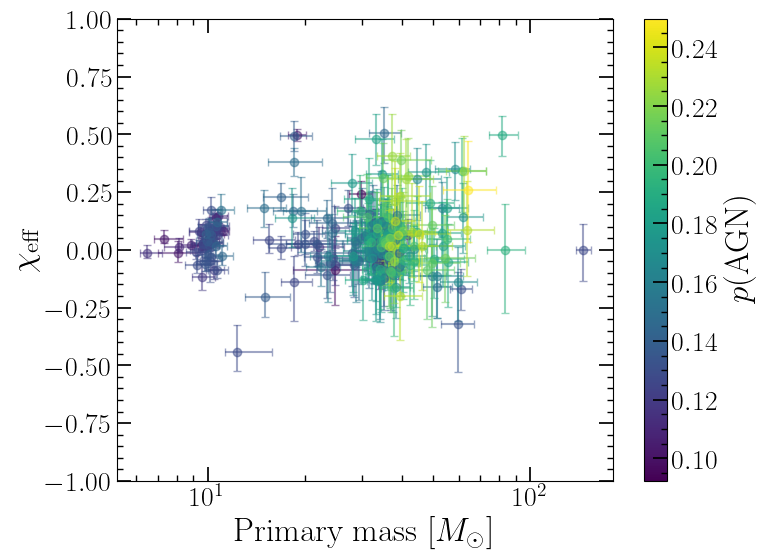

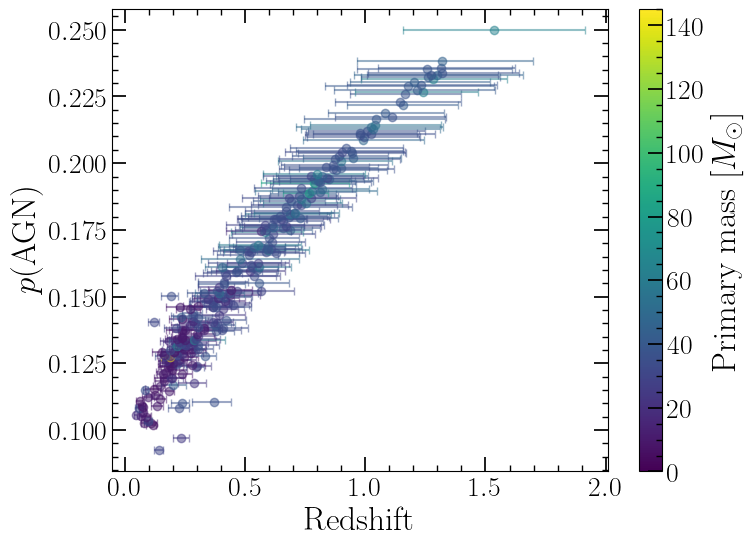

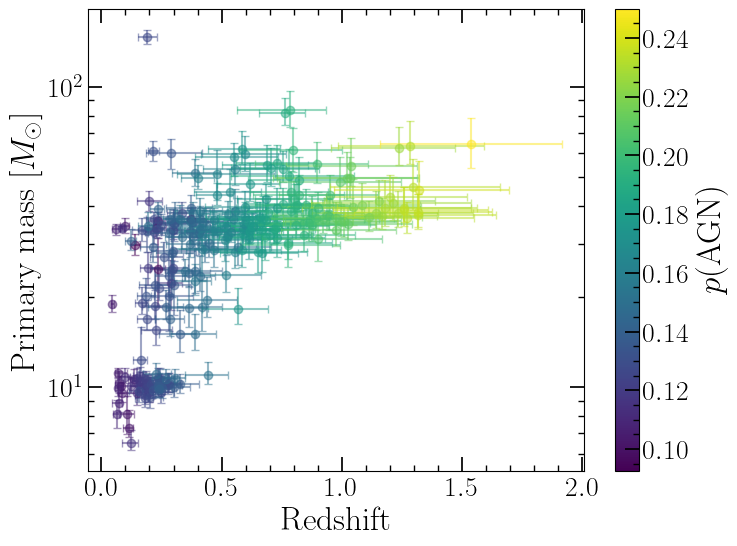

In [ ]:
reweight_PE_json_path = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/real_PEsamples_reweight_gwtc5.json'
with open(reweight_PE_json_path, 'r') as f:
    reweight_PEdict = json.load(f)

norm = plt.Normalize(vmin=min(probdict_use.items(), key=lambda x: (x[1], x[0]))[1], vmax=max(probdict_use.items(), key=lambda x: (x[1], x[0]))[1])
norm_mass = plt.Normalize(vmin=0, vmax=145)

fig, ax = plt.subplots(figsize=(8,6))
fig2, ax2 = plt.subplots(figsize=(8,6))
fig3, ax3 = plt.subplots(figsize=(8,6))
for key in gw_evidence_dict.keys():

    # if key.split('_')[0] != 'GW190521':
    #     continue

    path = reweight_PEdict[key]
    
    with h5py.File(path, 'r') as f:
        approximant = list(f.keys())[0]
        posterior_samples = f[approximant]['posterior_samples']

        x = posterior_samples['mass_1_source']
        y = posterior_samples['chi_eff']
        z = posterior_samples['redshift']

        x16, x50, x84 = np.quantile(x, [0.16, 0.50, 0.84])
        y16, y50, y84 = np.quantile(y, [0.16, 0.50, 0.84])
        z16, z50, z84 = np.quantile(z, [0.16, 0.50, 0.84])
    
    ax3.errorbar(
        z50,
        x50,
        xerr=[[z50 - z16], [z84 - z50]],
        yerr=[[x50 - x16], [x84 - x50]],
        fmt='o',
        color=plt.cm.viridis(norm(probdict_use[key])),
        capsize=3,
        alpha=0.5,
        zorder=probdict_use[key]
    )

    ax2.errorbar(
        z50,
        probdict_use[key],
        xerr=[[z50 - z16], [z84 - z50]],
        fmt='o',
        color=plt.cm.viridis(norm_mass(x50)),
        capsize=3,
        alpha=0.5,
        zorder=probdict_use[key]
    )

    ax.errorbar(
        x50,
        y50,
        xerr=[[x50 - x16], [x84 - x50]],
        yerr=[[y50 - y16], [y84 - y50]],
        fmt='o',
        color=plt.cm.viridis(norm(probdict_use[key])),
        capsize=3,
        alpha=0.5,
        zorder=probdict_use[key]
    )

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, label=r"$p(\rm{AGN})$")
fig2.colorbar(plt.cm.ScalarMappable(norm=norm_mass, cmap="viridis"), ax=ax2, label=r"Primary mass [$M_{\odot}$]")
fig3.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax3, label=r"$p(\rm{AGN})$")
# ax.vlines([45, 120], -1, 1, color='grey', linestyles='dashed', label='Mass gap')
ax.semilogx()
ax.set_ylim(-1, 1)
ax.set_xlabel(r'Primary mass [$M_{\odot}$]')
ax.set_ylabel(r'$\chi_{\rm eff}$')

ax2.set_xlabel(r'Redshift')
ax2.set_ylabel(r'$p(\mathrm{AGN})$')

ax3.set_xlabel(r'Redshift')
ax3.set_ylabel(r'Primary mass [$M_{\odot}$]')
ax3.semilogy()

# fig.savefig(f'/home/lucas/Documents/PhD/darksirenpop/p26plots_v2/xeff_mass_{LTHRESH_STRING}.pdf', bbox_inches='tight')
# fig2.savefig(f'/home/lucas/Documents/PhD/darksirenpop/p26plots_v2/pagn_z_{LTHRESH_STRING}.pdf', bbox_inches='tight')
# fig3.savefig(f'/home/lucas/Documents/PhD/darksirenpop/p26plots_v2/mass_z_{LTHRESH_STRING}.pdf', bbox_inches='tight')

# ax.legend(loc='upper left')
plt.show()


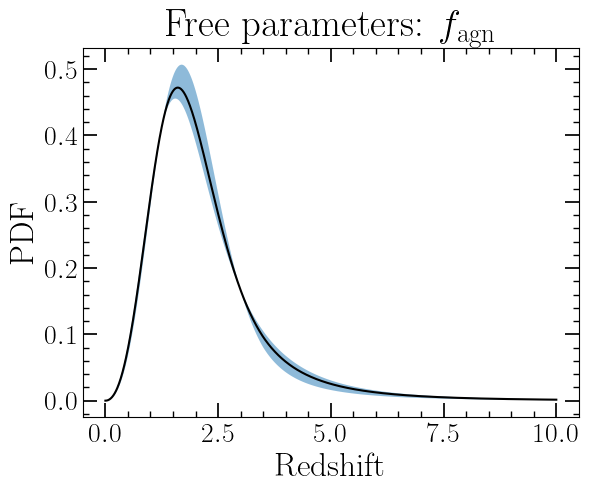

In [ ]:
# plt.figure()
# plt.hist(fsamps, bins=30, density=True)
# plt.plot(cfg_plot.LOG_LLH_X_AX, fagn_posterior)
# plt.show()

# cmap = plt.cm.viridis
# plt.figure()
# for fagn in np.linspace(0, 1, 10):
#     plt.plot(cfg.Z_INTEGRAL_AX, fagn * agn_redshift_population_prior + (1 - fagn) * alt_redshift_population_prior, c=cmap(fagn))
# plt.show()


N = int(1e5)
fagn_posterior = get_pdfs(corrected_log_llh_plot, axis=cfg_plot.LOG_LLH_X_AX)
fsamps = sample_pdf(fagn_posterior, cfg_plot.LOG_LLH_X_AX, N)
zpop_posts = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
for i, fagn in enumerate(fsamps):
    # plt.plot(cfg.Z_INTEGRAL_AX, fagn * agn_redshift_population_prior + (1 - fagn) * alt_redshift_population_prior, color='black', alpha=0.03)
    zpop_posts[i,:] = fagn * agn_redshift_population_prior + (1 - fagn) * alt_redshift_population_prior

plt.figure()
plt.title(r'Free parameters: $f_{\rm agn}$')
plt.plot(cfg.Z_INTEGRAL_AX, np.median(zpop_posts, axis=0), color='black')
plt.fill_between(cfg.Z_INTEGRAL_AX, np.quantile(zpop_posts, 0.05, axis=0), np.quantile(zpop_posts, 0.95, axis=0), alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.show()


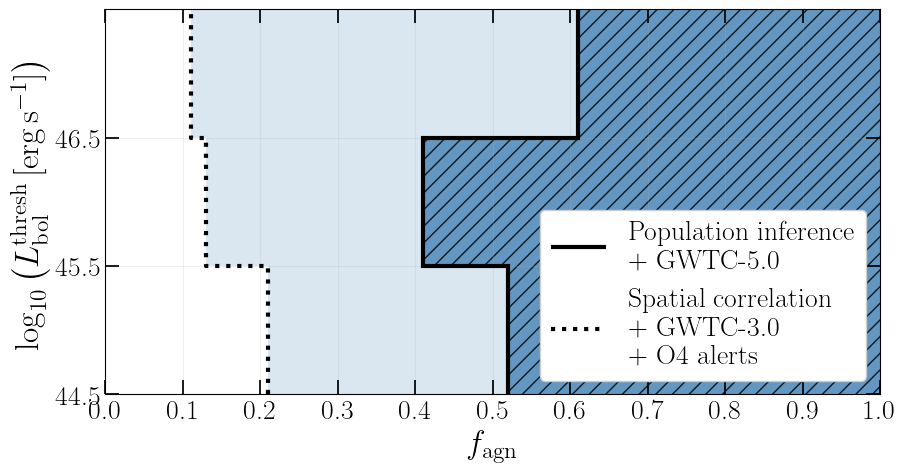

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

lumthreshes = [45, 46, 47]
# values = [1 - 0.45, 1 - 0.36, 1 - 0.60]  # 90%
# ax.barh(47, 0.04, height=1.0, alpha=0.8, color='steelblue', linewidth=3, hatch='//',)

values = [1 - 0.52, 1 - 0.41, 1 - 0.61]  # 95%
right_edge = 1
bars = ax.barh(lumthreshes, values, left=[1 - v for v in values], height=1.0, alpha=0.8, color='steelblue', linewidth=3, hatch='//',)

# Get the left edge of each bar
x_left = [bar.get_x() for bar in bars]
# Get the y boundaries
y_bottom = bars[0].get_y()
y_edges = [bar.get_y() + bar.get_height() for bar in bars]
# Build ONE continuous path along the left edges
x_line = [x_left[0]]
y_line = [y_bottom]
for i in range(len(bars)):
    # Go vertically up the left edge
    x_line.append(x_left[i])
    y_line.append(y_edges[i])
    # Connect horizontally to the next bar's left edge
    if i < len(bars) - 1:
        x_line.append(x_left[i + 1])
        y_line.append(y_edges[i])
ax.plot(
    x_line,
    y_line,
    color='black',
    linewidth=3,
    solid_capstyle='butt',
    solid_joinstyle='miter',
    label='Population inference \n+ GWTC-5.0'
)

lumthreshes = [45, 46, 47]
# values = [1 - 0.16, 1 - 0.10, 1 - 0.09]  # 90%
values = [1 - 0.21, 1 - 0.13, 1 - 0.11]  # 95%
right_edge = 1
bars = ax.barh(lumthreshes, values, left=[1 - v for v in values], height=1.0, color='steelblue', alpha=0.2, linewidth=3)

# Get the left edge of each bar
x_left = [bar.get_x() for bar in bars]
# Get the y boundaries
y_bottom = bars[0].get_y()
y_edges = [bar.get_y() + bar.get_height() for bar in bars]
# Build ONE continuous path along the left edges
x_line = [x_left[0]]
y_line = [y_bottom]
for i in range(len(bars)):
    # Go vertically up the left edge
    x_line.append(x_left[i])
    y_line.append(y_edges[i])
    # Connect horizontally to the next bar's left edge
    if i < len(bars) - 1:
        x_line.append(x_left[i + 1])
        y_line.append(y_edges[i])
ax.plot(
    x_line,
    y_line,
    color='black',
    linewidth=3,
    solid_capstyle='butt',
    solid_joinstyle='miter',
    linestyle='dotted',
    label='Spatial correlation \n+ GWTC-3.0 \n+ O4 alerts'
)

ax.set_xlabel(r'$f_{\rm agn}$')
ax.set_ylabel(r'$\log_{10} \left( L_{\rm bol}^{\rm thresh} \, [\mathrm{erg \, s^{-1}}] \right)$')
ax.set_yticks([44.5, 45.5, 46.5])
ax.set_yticklabels([44.5, 45.5, 46.5])
ax.set_xticks(np.around(np.arange(0, 1.1, 0.1), 1))
ax.set_xticklabels(np.around(np.arange(0, 1.1, 0.1), 1))
ax.set_ylim(44.5, 47.5)
ax.set_xlim(0, 1)
ax.minorticks_off()
ax.grid(alpha=0.2)
ax.legend(framealpha=1, loc='lower right')
# plt.savefig(f'/home/lucas/Documents/PhD/darksirenpop/p26plots_v2/constraints_onecol.pdf', bbox_inches='tight')
plt.show()
